ライブラリのインストール

In [1]:
!pip install ImageHash torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.2 MB/s eta 0:00:00


In [4]:
!python -c "import torch; print(torch.__version__)"

2.10.0+cu128


In [5]:
import sklearn

print(sklearn.__version__)

1.6.1


In [2]:
import os
import re
import json
import math
import hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics.pairwise import cosine_similarity

# 近似重複チェック用
import imagehash

# 軽量埋め込み用
import torch
import torchvision
from torchvision import transforms

In [3]:
# 例:
# dataset/
#   good/
#   bad/

DATASET_DIR = Path("/content/drive/MyDrive/dataset")
GOOD_DIR = DATASET_DIR / "good"
BAD_DIR = DATASET_DIR / "bad"

assert GOOD_DIR.exists(), f"Not found: {GOOD_DIR}"
assert BAD_DIR.exists(), f"Not found: {BAD_DIR}"

画像データからの情報取得

In [4]:
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def list_image_files(folder: Path):
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS])

good_files = list_image_files(GOOD_DIR)
bad_files = list_image_files(BAD_DIR)

print(f"good: {len(good_files)}")
print(f"bad : {len(bad_files)}")
print(f"total: {len(good_files) + len(bad_files)}")

good: 1000
bad : 350
total: 1350


In [5]:
def sha256_of_file(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def parse_filename_metadata(filename: str):
    """
    例:
    GOOD_IMG_2E420008_2025-01-13_15-11-21_000255_GlossRatio_cropped.png
    05_IMG_2E420008_2025-01-17_15-30-45_000667_GlossRatio_cropped.png

    抽出したい候補:
    - product_id: 2E420008
    - date: 2025-01-13
    - time: 15-11-21
    - seq: 000255
    - suffix: GlossRatio_cropped
    """
    stem = Path(filename).stem

    # product_id
    m_pid = re.search(r"_([A-Z0-9]{6,})_", stem)
    product_id = m_pid.group(1) if m_pid else None

    # date
    m_date = re.search(r"(\d{4}-\d{2}-\d{2})", stem)
    date_str = m_date.group(1) if m_date else None

    # time
    m_time = re.search(r"(\d{2}-\d{2}-\d{2})", stem)
    time_str = m_time.group(1) if m_time else None

    # seq
    m_seq = re.search(r"_(\d{6})_", stem)
    seq = m_seq.group(1) if m_seq else None

    # prefix
    parts = stem.split("_")
    prefix = parts[0] if len(parts) > 0 else None

    return {
        "prefix": prefix,
        "product_id": product_id,
        "date_str": date_str,
        "time_str": time_str,
        "seq": seq,
    }

def collect_metadata(file_paths, label):
    rows = []
    for path in tqdm(file_paths, desc=f"collect {label}"):
        row = {
            "path": str(path),
            "label": label,
            "filename": path.name,
            "stem": path.stem,
            "suffix": path.suffix.lower(),
            "file_size_bytes": path.stat().st_size,
        }

        meta = parse_filename_metadata(path.name)
        row.update(meta)

        try:
            with Image.open(path) as img:
                row["width"] = img.width
                row["height"] = img.height
                row["mode"] = img.mode
        except Exception as e:
            row["width"] = None
            row["height"] = None
            row["mode"] = None
            row["read_error"] = str(e)

        try:
            row["sha256"] = sha256_of_file(path)
        except Exception as e:
            row["sha256"] = None
            row["hash_error"] = str(e)

        rows.append(row)

    return pd.DataFrame(rows)

df_good = collect_metadata(good_files, "good")
df_bad = collect_metadata(bad_files, "bad")
df = pd.concat([df_good, df_bad], ignore_index=True)

print(df.head())
print(df.shape)

collect bad: 100%|██████████| 350/350 [07:56<00:00,  1.36s/it]

                                                path label  \
0  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   
1  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   
2  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   
3  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   
4  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   

                                            filename  \
0  GOOD_IMG_2E420008_2025-01-13_15-11-21_000255_G...   
1  GOOD_IMG_2E420008_2025-01-13_15-14-08_000264_G...   
2  GOOD_IMG_2E420008_2025-01-13_15-15-43_000276_G...   
3  GOOD_IMG_2E420008_2025-01-13_15-17-05_000289_G...   
4  GOOD_IMG_2E420008_2025-01-13_15-33-24_000307_G...   

                                                stem suffix  file_size_bytes  \
0  GOOD_IMG_2E420008_2025-01-13_15-11-21_000255_G...   .png          1493755   
1  GOOD_IMG_2E420008_2025-01-13_15-14-08_000264_G...   .png          1490926   
2  GOOD_IMG_2E420008_2025-01-13_15-15-43_000276_G.

EDA

In [6]:
print("Class distribution:")
print(df["label"].value_counts())

print("\nImage size distribution:")
print(df[["width", "height"]].value_counts().head(10))

print("\nMode distribution:")
print(df["mode"].value_counts(dropna=False))

print("\nAny read errors?")
print(df.get("read_error", pd.Series(dtype=str)).dropna().head())

Class distribution:
label
good    1000
bad      350
Name: count, dtype: int64

Image size distribution:
width  height
1024   1024      1350
Name: count, dtype: int64

Mode distribution:
mode
RGB    1350
Name: count, dtype: int64

Any read errors?
Series([], dtype: object)


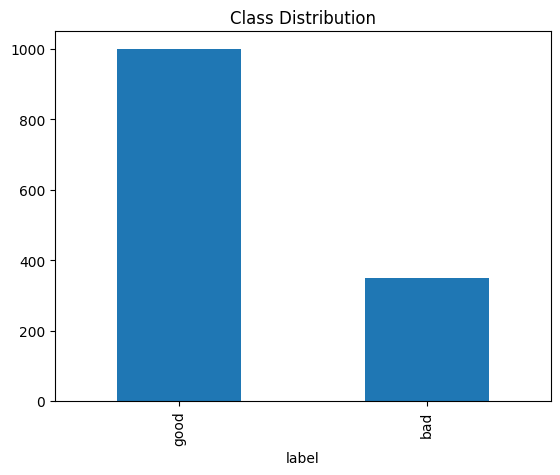

In [7]:
# クラス比可視化
ax = df["label"].value_counts().plot(kind="bar", title="Class Distribution")
plt.show()

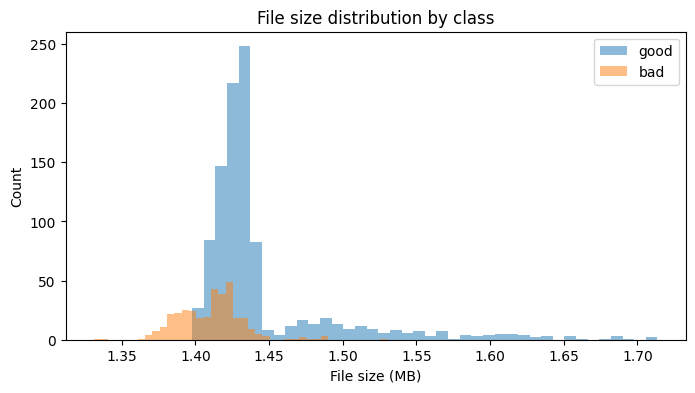

In [8]:
# ファイルサイズ分布
df["file_size_mb"] = df["file_size_bytes"] / (1024 * 1024)

plt.figure(figsize=(8, 4))
for label in ["good", "bad"]:
    subset = df[df["label"] == label]["file_size_mb"]
    plt.hist(subset, bins=40, alpha=0.5, label=label)
plt.xlabel("File size (MB)")
plt.ylabel("Count")
plt.title("File size distribution by class")
plt.legend()
plt.show()

サンプル画像

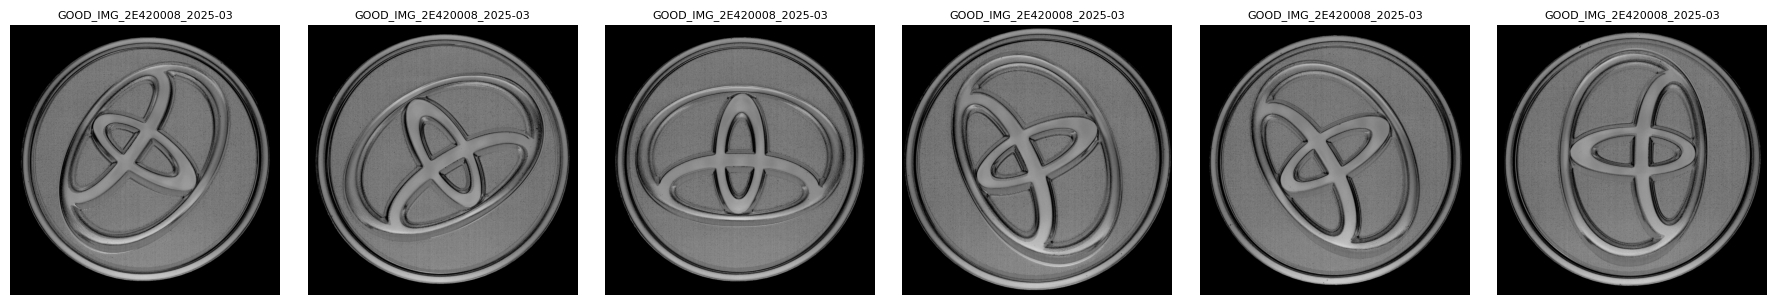

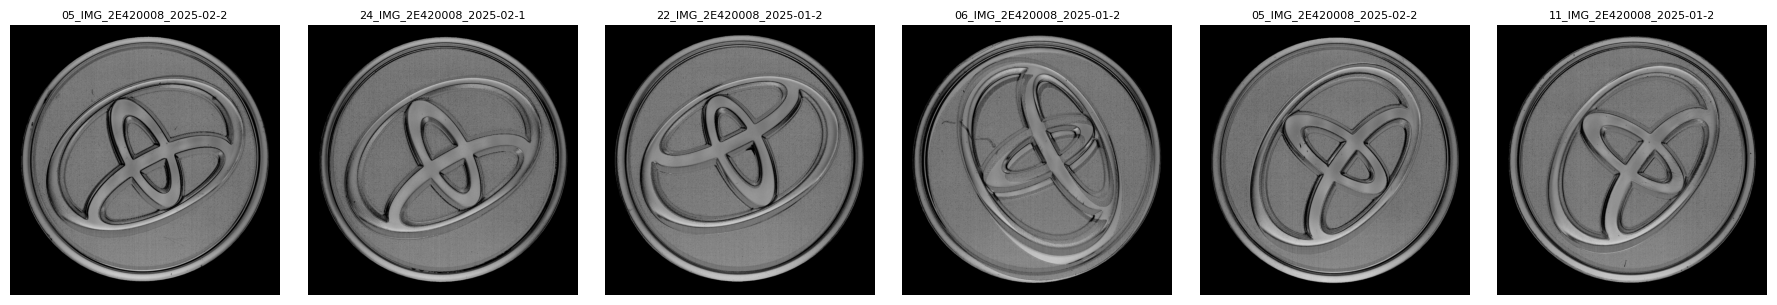

In [9]:
def show_samples(df, label, n=8, seed=42):
    sample_df = df[df["label"] == label].sample(min(n, len(df[df["label"] == label])), random_state=seed)
    fig, axes = plt.subplots(1, len(sample_df), figsize=(3 * len(sample_df), 3))
    if len(sample_df) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        img = Image.open(row["path"])
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        ax.set_title(Path(row["path"]).name[:25], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(df, "good", n=6)
show_samples(df, "bad", n=6)

重複チェック

In [10]:
dup_sha = df[df["sha256"].duplicated(keep=False)].sort_values("sha256")
print(f"Exact duplicate files: {len(dup_sha)} rows")
dup_sha[["label", "filename", "sha256"]].head(20)

Exact duplicate files: 0 rows


,label,filename,sha256


In [11]:
if len(dup_sha) > 0:
    print(dup_sha.groupby("sha256").size().sort_values(ascending=False).head(20))

In [12]:
sha_label_nunique = df.groupby("sha256")["label"].nunique()
cross_label_exact_dup_hashes = sha_label_nunique[sha_label_nunique > 1].index.tolist()

cross_label_exact_dups = df[df["sha256"].isin(cross_label_exact_dup_hashes)].sort_values("sha256")
print(f"Cross-label exact duplicates: {len(cross_label_exact_dups)}")
cross_label_exact_dups[["label", "filename", "sha256"]].head(20)

Cross-label exact duplicates: 0


,label,filename,sha256


Hashによる重複チェック

In [13]:
def compute_phash(path):
    with Image.open(path) as img:
        img = img.convert("L")
        return str(imagehash.phash(img))

def compute_dhash(path):
    with Image.open(path) as img:
        img = img.convert("L")
        return str(imagehash.dhash(img))

phashes = []
dhashes = []

for path in tqdm(df["path"], desc="perceptual hash"):
    try:
        phashes.append(compute_phash(path))
        dhashes.append(compute_dhash(path))
    except Exception:
        phashes.append(None)
        dhashes.append(None)

df["phash"] = phashes
df["dhash"] = dhashes

perceptual hash: 100%|██████████| 1350/1350 [01:06<00:00, 20.26it/s]


In [14]:
# phash 完全一致
dup_phash = df[df["phash"].duplicated(keep=False)].sort_values("phash")
print(f"Same pHash rows: {len(dup_phash)}")
dup_phash[["label", "filename", "phash"]].head(20)

Same pHash rows: 178


,label,filename,phash
838,good,GOOD_IMG_2E420008_2025-03-25_15-08-08_001413_G...,80325ebd69d23ccb
758,good,GOOD_IMG_2E420008_2025-03-25_13-02-40_000663_G...,80325ebd69d23ccb
669,good,GOOD_IMG_2E420008_2025-03-24_16-21-02_001702_G...,803d5fd23b856cb4
342,good,GOOD_IMG_2E420008_2025-03-21_12-00-13_000368_G...,803d5fd23b856cb4
1116,bad,05_IMG_2E420008_2025-02-24_15-16-24_000330_Glo...,81295eb76ed038cb
1091,bad,05_IMG_2E420008_2025-02-24_14-38-06_000109_Glo...,81295eb76ed038cb
351,good,GOOD_IMG_2E420008_2025-03-21_12-09-28_000455_G...,812f5eb468d235cb
333,good,GOOD_IMG_2E420008_2025-03-21_11-55-04_000311_G...,812f5eb468d235cb
881,good,GOOD_IMG_2E420008_2025-03-26_13-22-53_000373_G...,81324ebd69d23ccb
810,good,GOOD_IMG_2E420008_2025-03-25_14-20-51_001147_G...,81324ebd69d23ccb


In [15]:
# クラス横断 pHash 重複
phash_label_nunique = df.groupby("phash")["label"].nunique()
cross_label_phash = phash_label_nunique[phash_label_nunique > 1].index.tolist()

cross_label_phash_df = df[df["phash"].isin(cross_label_phash)].sort_values("phash")
print(f"Cross-label perceptual duplicates: {len(cross_label_phash_df)}")
cross_label_phash_df[["label", "filename", "phash"]].head(20)

Cross-label perceptual duplicates: 2


,label,filename,phash
587,good,GOOD_IMG_2E420008_2025-03-24_14-21-35_000974_G...,91325ebd69d238c9
1069,bad,05_IMG_2E420008_2025-01-20_12-06-12_000668_Glo...,91325ebd69d238c9


CNN埋め込みで近傍類似画像を確認

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights)

# classifier を外して特徴量抽出器にする
feature_extractor = torch.nn.Sequential(
    model.features,
    model.avgpool,
    torch.nn.Flatten()
).to(device).eval()

embed_transform = weights.transforms()

device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 94.9MB/s]


In [17]:
@torch.no_grad()
def extract_embedding(path):
    img = Image.open(path).convert("RGB")
    x = embed_transform(img).unsqueeze(0).to(device)
    feat = feature_extractor(x)
    feat = feat.cpu().numpy().squeeze()
    feat = feat / (np.linalg.norm(feat) + 1e-12)
    return feat

embeddings = []
for path in tqdm(df["path"], desc="extract embeddings"):
    try:
        embeddings.append(extract_embedding(path))
    except Exception:
        embeddings.append(None)

valid_mask = [e is not None for e in embeddings]
df_valid = df[valid_mask].copy().reset_index(drop=True)
X = np.stack([e for e in embeddings if e is not None], axis=0)

print(df_valid.shape, X.shape)

extract embeddings: 100%|██████████| 1350/1350 [00:46<00:00, 28.85it/s]

(1350, 18) (1350, 1280)


In [18]:
# コサイン類似度
sim = cosine_similarity(X)

# 自分自身を除外
np.fill_diagonal(sim, -1.0)

# 類似度上位ペアを抽出
pairs = []
threshold = 0.995  # 厳しめ。必要に応じて 0.99 / 0.98 に下げる

for i in range(sim.shape[0]):
    js = np.where(sim[i] >= threshold)[0]
    for j in js:
        if i < j:
            pairs.append({
                "idx1": i,
                "idx2": j,
                "sim": sim[i, j],
                "label1": df_valid.loc[i, "label"],
                "label2": df_valid.loc[j, "label"],
                "path1": df_valid.loc[i, "path"],
                "path2": df_valid.loc[j, "path"],
                "product_id1": df_valid.loc[i, "product_id"],
                "product_id2": df_valid.loc[j, "product_id"],
            })

pairs_df = pd.DataFrame(pairs).sort_values("sim", ascending=False)
print(pairs_df.head(20))
print(f"Similar pairs >= {threshold}: {len(pairs_df)}")

     idx1  idx2       sim label1 label2  \
83    570   865  0.997301   good   good   
118   762   777  0.996856   good   good   
33    346   347  0.996769   good   good   
37    368   372  0.996764   good   good   
42    382   392  0.996586   good   good   
105   688   730  0.996563   good   good   
24    318   738  0.996527   good   good   
114   758   807  0.996499   good   good   
62    512   515  0.996452   good   good   
112   745   824  0.996403   good   good   
87    591   594  0.996368   good   good   
89    608   778  0.996333   good   good   
115   758   838  0.996329   good   good   
13    155   161  0.996312   good   good   
58    461   618  0.996304   good   good   
111   744   790  0.996251   good   good   
131   821   881  0.996248   good   good   
85    581   781  0.996159   good   good   
21    298   382  0.996141   good   good   
25    320   323  0.996084   good   good   

                                                 path1  \
83   /content/drive/MyDrive/dataset/go

In [19]:
cross_label_pairs = pairs_df[pairs_df["label1"] != pairs_df["label2"]]
print(f"Cross-label similar pairs: {len(cross_label_pairs)}")
cross_label_pairs.head(20)

Cross-label similar pairs: 0


,idx1,idx2,sim,label1,label2,path1,path2,product_id1,product_id2


類似画像の可視化

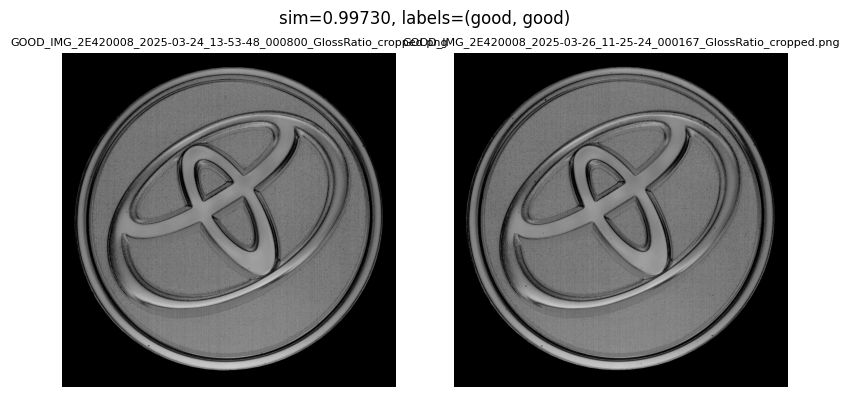

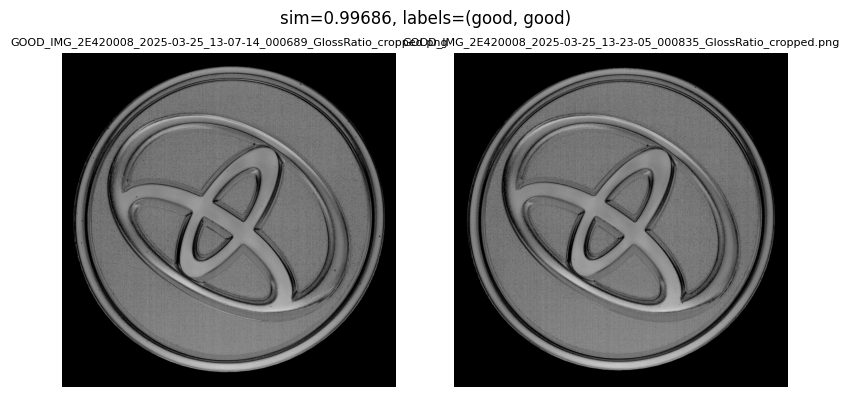

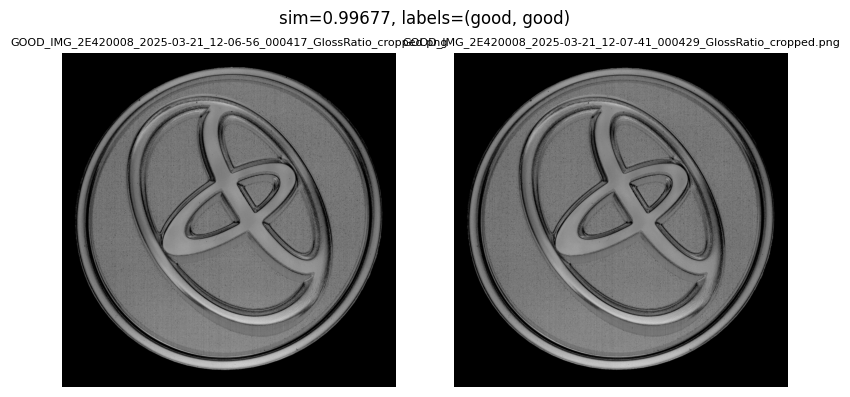

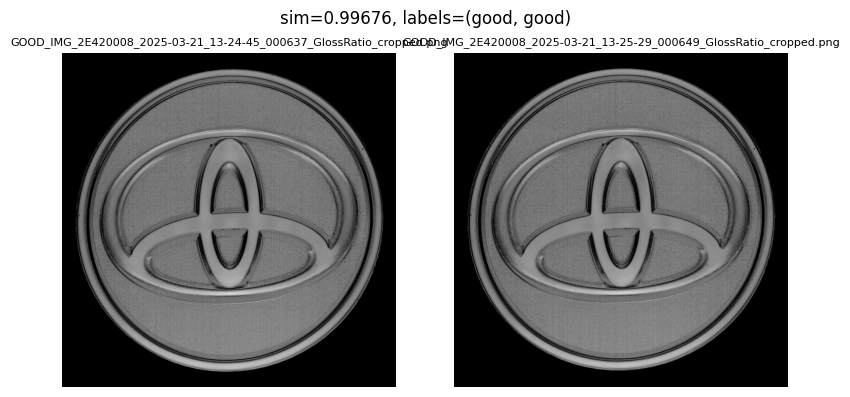

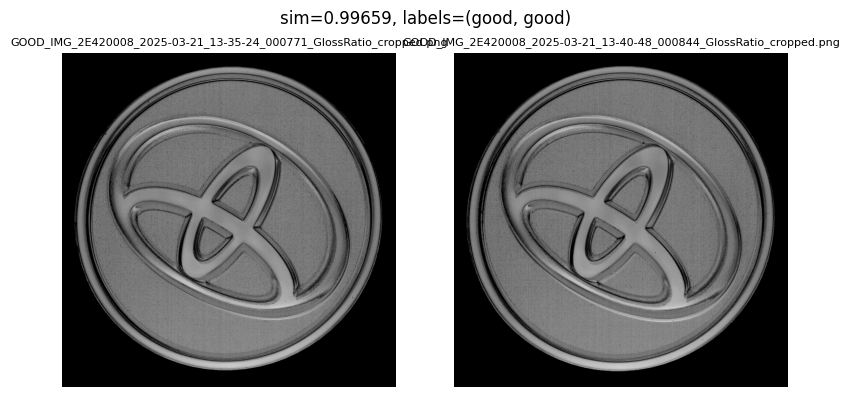

In [20]:
def show_pair(path1, path2, title=None):
    img1 = Image.open(path1)
    img2 = Image.open(path2)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img1, cmap="gray" if img1.mode == "L" else None)
    axes[0].set_title(Path(path1).name, fontsize=8)
    axes[0].axis("off")

    axes[1].imshow(img2, cmap="gray" if img2.mode == "L" else None)
    axes[1].set_title(Path(path2).name, fontsize=8)
    axes[1].axis("off")

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# 上位数件だけ表示
for _, row in pairs_df.head(5).iterrows():
    show_pair(row["path1"], row["path2"], title=f"sim={row['sim']:.5f}, labels=({row['label1']}, {row['label2']})")

データセットのsplit

In [21]:
from collections import defaultdict, deque

CNN 類似ペアから connected components でクラスタを作って group_id に変換する

その group_id を使って train/val/test を作成する

In [22]:
def build_similarity_clusters_from_pairs(
    df_valid: pd.DataFrame,
    pairs_df: pd.DataFrame,
    sim_threshold: float = 0.995,
):
    """
    高類似ペアから無向グラフを作り、connected components を cluster_id として返す。

    Parameters
    ----------
    df_valid : pd.DataFrame
        埋め込み計算済み画像の DataFrame。index は pairs_df の idx1/idx2 と対応している想定。
    pairs_df : pd.DataFrame
        類似ペア一覧。少なくとも idx1, idx2, sim を含む。
    sim_threshold : float
        この値以上のペアのみエッジとして採用。

    Returns
    -------
    cluster_df : pd.DataFrame
        各サンプルに対して cluster_id を付与した DataFrame
    component_members : dict
        {cluster_id: [member_indices]} の辞書
    """
    # 対象ペアを閾値で絞る
    edges_df = pairs_df[pairs_df["sim"] >= sim_threshold].copy()

    # 全ノード（孤立ノードも含む）
    nodes = list(df_valid.index)

    # 隣接リスト作成
    graph = defaultdict(set)
    for _, row in edges_df.iterrows():
        i = int(row["idx1"])
        j = int(row["idx2"])
        graph[i].add(j)
        graph[j].add(i)

    # connected components
    visited = set()
    component_members = {}
    cluster_id_map = {}

    current_cluster_id = 0

    for node in nodes:
        if node in visited:
            continue

        # BFS / DFS
        queue = deque([node])
        visited.add(node)
        members = []

        while queue:
            cur = queue.popleft()
            members.append(cur)

            for nei in graph[cur]:
                if nei not in visited:
                    visited.add(nei)
                    queue.append(nei)

        component_members[current_cluster_id] = sorted(members)
        for m in members:
            cluster_id_map[m] = current_cluster_id

        current_cluster_id += 1

    cluster_df = df_valid.copy()
    cluster_df["cluster_id"] = cluster_df.index.map(cluster_id_map)

    return cluster_df, component_members

In [23]:
cluster_df, component_members = build_similarity_clusters_from_pairs(
    df_valid=df_valid,
    pairs_df=pairs_df,
    sim_threshold=0.995,
)

print(cluster_df.head())
print(f"num clusters: {cluster_df['cluster_id'].nunique()}")

                                                path label  \
0  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   
1  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   
2  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   
3  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   
4  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good   

                                            filename  \
0  GOOD_IMG_2E420008_2025-01-13_15-11-21_000255_G...   
1  GOOD_IMG_2E420008_2025-01-13_15-14-08_000264_G...   
2  GOOD_IMG_2E420008_2025-01-13_15-15-43_000276_G...   
3  GOOD_IMG_2E420008_2025-01-13_15-17-05_000289_G...   
4  GOOD_IMG_2E420008_2025-01-13_15-33-24_000307_G...   

                                                stem suffix  file_size_bytes  \
0  GOOD_IMG_2E420008_2025-01-13_15-11-21_000255_G...   .png          1493755   
1  GOOD_IMG_2E420008_2025-01-13_15-14-08_000264_G...   .png          1490926   
2  GOOD_IMG_2E420008_2025-01-13_15-15-43_000276_G.

クラスタサイズを確認するコード

In [24]:
cluster_sizes = (
    cluster_df.groupby("cluster_id")
    .size()
    .reset_index(name="cluster_size")
    .sort_values("cluster_size", ascending=False)
)

print(cluster_sizes.head(20))
print(cluster_sizes["cluster_size"].describe())

     cluster_id  cluster_size
352         352             9
394         394             7
280         280             7
306         306             6
553         553             6
299         299             5
583         583             5
26           26             4
284         284             4
347         347             4
479         479             4
417         417             4
441         441             4
308         308             4
677         677             4
350         350             4
349         349             3
561         561             3
32           32             3
480         480             3
count    1228.000000
mean        1.099349
std         0.552006
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         9.000000
Name: cluster_size, dtype: float64


In [25]:
# サイズ分布
print(cluster_sizes["cluster_size"].value_counts().sort_index().head(20))

cluster_size
1    1170
2      27
3      15
4       9
5       2
6       2
7       2
9       1
Name: count, dtype: int64


In [26]:
# 大きいクラスタだけ確認
large_clusters = cluster_sizes[cluster_sizes["cluster_size"] >= 3]
print(f"clusters with size >= 3: {len(large_clusters)}")
print(large_clusters.head(20))

clusters with size >= 3: 31
     cluster_id  cluster_size
352         352             9
394         394             7
280         280             7
306         306             6
553         553             6
299         299             5
583         583             5
26           26             4
284         284             4
347         347             4
479         479             4
417         417             4
441         441             4
308         308             4
677         677             4
350         350             4
349         349             3
561         561             3
32           32             3
480         480             3


クラスタごとのラベル混在確認

In [27]:
cluster_label_stats = (
    cluster_df.groupby("cluster_id")["label"]
    .agg(
        n_samples="count",
        n_unique_labels="nunique",
        labels=lambda x: sorted(x.unique().tolist()),
        good_count=lambda x: (x == "good").sum(),
        bad_count=lambda x: (x == "bad").sum(),
    )
    .reset_index()
    .sort_values(["n_unique_labels", "n_samples"], ascending=[False, False])
)

print(cluster_label_stats.head(20))

     cluster_id  n_samples  n_unique_labels  labels  good_count  bad_count
352         352          9                1  [good]           9          0
280         280          7                1  [good]           7          0
394         394          7                1  [good]           7          0
306         306          6                1  [good]           6          0
553         553          6                1  [good]           6          0
299         299          5                1  [good]           5          0
583         583          5                1  [good]           5          0
26           26          4                1  [good]           4          0
284         284          4                1  [good]           4          0
308         308          4                1  [good]           4          0
347         347          4                1  [good]           4          0
350         350          4                1  [good]           4          0
417         417          

In [28]:
mixed_clusters = cluster_label_stats[cluster_label_stats["n_unique_labels"] > 1]
print(f"mixed-label clusters: {len(mixed_clusters)}")
print(mixed_clusters.head(20))

mixed-label clusters: 0
Empty DataFrame
Columns: [cluster_id, n_samples, n_unique_labels, labels, good_count, bad_count]
Index: []


元の df に group_id を戻す

In [29]:
df_with_groups = df.copy()

path_to_cluster = cluster_df.set_index("path")["cluster_id"].to_dict()

# 埋め込み計算できなかった画像は一旦 NaN
df_with_groups["group_id"] = df_with_groups["path"].map(path_to_cluster)

In [30]:
missing_mask = df_with_groups["group_id"].isna()
print("missing group_id rows:", missing_mask.sum())

# 埋め込み失敗分は固有groupを与える
if missing_mask.sum() > 0:
    start_id = int(df_with_groups["group_id"].dropna().max()) + 1 if df_with_groups["group_id"].notna().any() else 0
    fallback_ids = range(start_id, start_id + missing_mask.sum())
    df_with_groups.loc[missing_mask, "group_id"] = list(fallback_ids)

df_with_groups["group_id"] = df_with_groups["group_id"].astype(int)
print(df_with_groups[["path", "label", "group_id"]].head())

missing group_id rows: 0
                                                path label  group_id
0  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good         0
1  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good         1
2  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good         2
3  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good         3
4  /content/drive/MyDrive/dataset/good/GOOD_IMG_2...  good         4


 group_id を使って train / val / test に分ける

In [32]:
def split_by_group_holdout(
    df: pd.DataFrame,
    group_col: str = "group_id",
    label_col: str = "label",
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
):
    """
    group 単位で holdout split。
    group ごとに代表ラベルを付けて stratify する簡易版。
    """

    assert abs(train_size + val_size + test_size - 1.0) < 1e-8

    # groupごとの代表ラベル
    group_summary = (
        df.groupby(group_col)[label_col]
        .agg(
            n_samples="count",
            n_unique_labels="nunique",
            majority_label=lambda x: x.mode().iloc[0]
        )
        .reset_index()
    )

    # まず train / temp
    train_groups, temp_groups = train_test_split(
        group_summary,
        test_size=(1.0 - train_size),
        stratify=group_summary["majority_label"],
        random_state=random_state,
    )

    # temp を val / test
    relative_test_size = test_size / (val_size + test_size)

    val_groups, test_groups = train_test_split(
        temp_groups,
        test_size=relative_test_size,
        stratify=temp_groups["majority_label"],
        random_state=random_state,
    )

    train_df = df[df[group_col].isin(train_groups[group_col])].copy()
    val_df   = df[df[group_col].isin(val_groups[group_col])].copy()
    test_df  = df[df[group_col].isin(test_groups[group_col])].copy()

    return train_df, val_df, test_df, group_summary

train/val/testへの分割

In [33]:
train_df, val_df, test_df, group_summary = split_by_group_holdout(
    df=df_with_groups,
    group_col="group_id",
    label_col="label",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42,
)

In [34]:
def summarize_split(train_df, val_df, test_df, label_col="label", group_col="group_id"):
    for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
        print(f"\n[{name}]")
        print(f"n_samples: {len(part)}")
        print(f"n_groups : {part[group_col].nunique()}")
        print(part[label_col].value_counts())
        print(part[label_col].value_counts(normalize=True))

In [35]:
summarize_split(train_df, val_df, test_df)


[train]
n_samples: 959
n_groups : 859
label
good    714
bad     245
Name: count, dtype: int64
label
good    0.744526
bad     0.255474
Name: proportion, dtype: float64

[val]
n_samples: 198
n_groups : 184
label
good    146
bad      52
Name: count, dtype: int64
label
good    0.737374
bad     0.262626
Name: proportion, dtype: float64

[test]
n_samples: 193
n_groups : 185
label
good    140
bad      53
Name: count, dtype: int64
label
good    0.725389
bad     0.274611
Name: proportion, dtype: float64


split 後のリーク最終確認

In [36]:
def check_group_leakage(train_df, val_df, test_df, group_col="group_id"):
    train_groups = set(train_df[group_col].unique())
    val_groups = set(val_df[group_col].unique())
    test_groups = set(test_df[group_col].unique())

    print("train-val overlap :", len(train_groups & val_groups))
    print("train-test overlap:", len(train_groups & test_groups))
    print("val-test overlap  :", len(val_groups & test_groups))

group leakage がないか確認

In [37]:
check_group_leakage(train_df, val_df, test_df, group_col="group_id")

train-val overlap : 0
train-test overlap: 0
val-test overlap  : 0


In [38]:
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

train_df.to_csv(OUTPUT_DIR / "train_group_split.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_group_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_group_split.csv", index=False)

print("saved:")
print(OUTPUT_DIR / "train_group_split.csv")
print(OUTPUT_DIR / "val_group_split.csv")
print(OUTPUT_DIR / "test_group_split.csv")

saved:
outputs/train_group_split.csv
outputs/val_group_split.csv
outputs/test_group_split.csv


In [39]:
summarize_split(train_df, val_df, test_df)


[train]
n_samples: 959
n_groups : 859
label
good    714
bad     245
Name: count, dtype: int64
label
good    0.744526
bad     0.255474
Name: proportion, dtype: float64

[val]
n_samples: 198
n_groups : 184
label
good    146
bad      52
Name: count, dtype: int64
label
good    0.737374
bad     0.262626
Name: proportion, dtype: float64

[test]
n_samples: 193
n_groups : 185
label
good    140
bad      53
Name: count, dtype: int64
label
good    0.725389
bad     0.274611
Name: proportion, dtype: float64


正規化

In [40]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

In [41]:
class SimpleImageDataset(Dataset):
    """
    mean/std 計算用のシンプル dataset
    """
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(row["path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img

In [42]:
def compute_mean_std(dataset, batch_size=32, num_workers=2):

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_images = 0

    for images in tqdm(loader):

        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)

        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)

        total_images += batch_samples

    mean /= total_images
    std /= total_images

    return mean, std

In [43]:
transform = transforms.Compose([
    transforms.Resize((384,384)),
    transforms.ToTensor()
])

In [44]:
train_dataset_for_stats = SimpleImageDataset(
    train_df,
    transform=transform
)

In [45]:
mean, std = compute_mean_std(train_dataset_for_stats)

print("mean:", mean)
print("std:", std)

100%|██████████| 30/30 [00:13<00:00,  2.19it/s]

mean: tensor([0.2890, 0.2890, 0.2890])
std: tensor([0.2283, 0.2283, 0.2283])


PyTorch Dataset 実装

In [46]:
class LogoDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)
        self.transform = transform

        self.label_map = {
            "good":0,
            "bad":1
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = row["path"]
        label = self.label_map[row["label"]]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [47]:
train_transform = transforms.Compose([

    transforms.Resize((384,384)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(mean, std)
])

In [48]:
val_transform = transforms.Compose([

    transforms.Resize((384,384)),

    transforms.ToTensor(),

    transforms.Normalize(mean, std)
])

In [49]:
train_dataset = LogoDataset(
    train_df,
    transform=train_transform
)

val_dataset = LogoDataset(
    val_df,
    transform=val_transform
)

test_dataset = LogoDataset(
    test_df,
    transform=val_transform
)

Dataloader

In [53]:
import torch.nn as nn

In [51]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [52]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 384, 384])
torch.Size([32])


In [54]:
good_count = (train_df["label"] == "good").sum()
bad_count = (train_df["label"] == "bad").sum()

total = good_count + bad_count

weight_good = total / good_count
weight_bad = total / bad_count

class_weights = torch.tensor([weight_good, weight_bad]).float()

print(class_weights)

tensor([1.3431, 3.9143])


In [55]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

Baseline

In [56]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    balanced_accuracy_score,
    accuracy_score,
)

import time

seed 固定

In [57]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


class weightsの作成

In [59]:
good_count = (train_df["label"] == "good").sum()
bad_count = (train_df["label"] == "bad").sum()

total = good_count + bad_count
weight_good = total / good_count
weight_bad = total / bad_count

class_weights = torch.tensor([weight_good, weight_bad], dtype=torch.float32).to(device)
print("class_weights:", class_weights)

class_weights: tensor([1.3431, 3.9143], device='cuda:0')


モデル構築

In [60]:
import torch.nn as nn
import torchvision


def build_model(model_name="resnet18", num_classes=2, pretrained=True):
    model_name = model_name.lower()

    if model_name == "resnet18":
        weights = torchvision.models.ResNet18_Weights.DEFAULT if pretrained else None
        model = torchvision.models.resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b0":
        weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = torchvision.models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "convnext_tiny":
        weights = torchvision.models.ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
        model = torchvision.models.convnext_tiny(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_v2_s":
        weights = torchvision.models.EfficientNet_V2_S_Weights.DEFAULT if pretrained else None
        model = torchvision.models.efficientnet_v2_s(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    return model

metric 計算

In [61]:
def compute_binary_metrics(y_true, y_pred):
    precision_bad, recall_bad, f1_bad, _ = precision_recall_fscore_support(
        y_true, y_pred,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0

    return {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "precision_bad": precision_bad,
        "recall_bad": recall_bad,
        "f1_bad": f1_bad,
        "false_negative_rate": false_negative_rate,
        "false_positive_rate": false_positive_rate,
        "specificity": specificity,
        "npv": npv,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "confusion_matrix": cm,
    }

In [62]:
def compute_metrics_from_probs(y_true, prob_bad, threshold):
    """
    prob_bad >= threshold を bad(1) として予測する
    """
    y_true = np.asarray(y_true)
    prob_bad = np.asarray(prob_bad)

    y_pred = (prob_bad >= threshold).astype(int)

    precision_bad, recall_bad, f1_bad, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0

    return {
        "threshold": threshold,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "precision_bad": precision_bad,
        "recall_bad": recall_bad,
        "f1_bad": f1_bad,
        "false_negative_rate": false_negative_rate,
        "false_positive_rate": false_positive_rate,
        "specificity": specificity,
        "npv": npv,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "confusion_matrix": cm,
        "y_pred": y_pred,
    }

In [63]:
def find_best_threshold_by_recall_constraint(
    pred_df,
    min_recall_bad=0.95,
    threshold_grid=None,
):
    """
    validation prediction dataframe から、
    recall_bad >= min_recall_bad を満たす threshold のうち
    precision_bad 最大のものを選ぶ。
    """
    if threshold_grid is None:
        threshold_grid = np.arange(0.05, 0.951, 0.01)

    y_true = pred_df["y_true"].values
    prob_bad = pred_df["prob_bad"].values

    rows = []
    for th in threshold_grid:
        metrics = compute_metrics_from_probs(y_true, prob_bad, threshold=th)

        rows.append({
            "threshold": th,
            "accuracy": metrics["accuracy"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "precision_bad": metrics["precision_bad"],
            "recall_bad": metrics["recall_bad"],
            "f1_bad": metrics["f1_bad"],
            "false_negative_rate": metrics["false_negative_rate"],
            "false_positive_rate": metrics["false_positive_rate"],
            "specificity": metrics["specificity"],
            "npv": metrics["npv"],
            "tn": metrics["tn"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
        })

    threshold_df = pd.DataFrame(rows)

    candidate_df = threshold_df[threshold_df["recall_bad"] >= min_recall_bad].copy()

    if len(candidate_df) == 0:
        best_row = threshold_df.sort_values(
            ["recall_bad", "precision_bad", "f1_bad"],
            ascending=[False, False, False]
        ).iloc[0]
    else:
        best_row = candidate_df.sort_values(
            ["precision_bad", "f1_bad", "threshold"],
            ascending=[False, False, False]
        ).iloc[0]

    return best_row, threshold_df

epoch 学習

In [64]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    start_time = time.perf_counter()

    pbar = tqdm(loader, desc="Train", leave=False)

    for batch in pbar:
        images, labels = batch

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

        pbar.set_postfix(loss=loss.item())

    epoch_time_sec = time.perf_counter() - start_time

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_labels, all_preds)
    metrics["epoch_time_sec"] = epoch_time_sec
    metrics["avg_train_time_per_image_ms"] = (epoch_time_sec / len(loader.dataset)) * 1000

    return epoch_loss, metrics

validation / test 評価

In [65]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, phase="Val"):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs_bad = []

    if device.type == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    pbar = tqdm(loader, desc=phase, leave=False)

    for batch in pbar:
        images, labels = batch

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs_bad.extend(probs[:, 1].detach().cpu().numpy().tolist())

    if device.type == "cuda":
        torch.cuda.synchronize()
    total_inference_time_sec = time.perf_counter() - start_time

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_labels, all_preds)

    metrics["total_inference_time_sec"] = total_inference_time_sec
    metrics["avg_inference_time_per_image_ms"] = (total_inference_time_sec / len(loader.dataset)) * 1000
    metrics["throughput_images_per_sec"] = len(loader.dataset) / total_inference_time_sec if total_inference_time_sec > 0 else 0.0

    pred_df = pd.DataFrame({
        "y_true": all_labels,
        "y_pred": all_preds,
        "prob_bad": all_probs_bad,
    })

    return epoch_loss, metrics, pred_df

学習全体

In [66]:
def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=10,
    monitor_metric="recall_bad",
    output_dir="outputs",
    model_name="resnet18",
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    best_score = -np.inf
    best_epoch = -1
    best_model_wts = copy.deepcopy(model.state_dict())

    history = []

    fit_start_time = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        print(f"\n===== Epoch {epoch}/{num_epochs} =====")

        train_loss, train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_metrics, val_pred_df = evaluate(
            model, val_loader, criterion, device, phase="Val"
        )

        if scheduler is not None:
            scheduler.step()

        val_score = val_metrics[monitor_metric]

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_metrics["accuracy"],
            "train_balanced_accuracy": train_metrics["balanced_accuracy"],
            "train_precision_bad": train_metrics["precision_bad"],
            "train_recall_bad": train_metrics["recall_bad"],
            "train_f1_bad": train_metrics["f1_bad"],
            "train_false_negative_rate": train_metrics["false_negative_rate"],
            "train_false_positive_rate": train_metrics["false_positive_rate"],
            "train_specificity": train_metrics["specificity"],
            "train_npv": train_metrics["npv"],
            "train_epoch_time_sec": train_metrics["epoch_time_sec"],
            "train_avg_time_per_image_ms": train_metrics["avg_train_time_per_image_ms"],
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_precision_bad": val_metrics["precision_bad"],
            "val_recall_bad": val_metrics["recall_bad"],
            "val_f1_bad": val_metrics["f1_bad"],
            "val_false_negative_rate": val_metrics["false_negative_rate"],
            "val_false_positive_rate": val_metrics["false_positive_rate"],
            "val_specificity": val_metrics["specificity"],
            "val_npv": val_metrics["npv"],
            "val_total_inference_time_sec": val_metrics["total_inference_time_sec"],
            "val_avg_inference_time_per_image_ms": val_metrics["avg_inference_time_per_image_ms"],
            "val_throughput_images_per_sec": val_metrics["throughput_images_per_sec"],
        }
        history.append(row)

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Acc: {train_metrics['accuracy']:.4f} | "
            f"BalAcc: {train_metrics['balanced_accuracy']:.4f} | "
            f"Prec_bad: {train_metrics['precision_bad']:.4f} | "
            f"Recall_bad: {train_metrics['recall_bad']:.4f} | "
            f"F1_bad: {train_metrics['f1_bad']:.4f} | "
            f"FNR: {train_metrics['false_negative_rate']:.4f} | "
            f"FPR: {train_metrics['false_positive_rate']:.4f} | "
            f"EpochTime(s): {train_metrics['epoch_time_sec']:.2f}"
        )

        print(
            f"Val   Loss: {val_loss:.4f} | "
            f"Acc: {val_metrics['accuracy']:.4f} | "
            f"BalAcc: {val_metrics['balanced_accuracy']:.4f} | "
            f"Prec_bad: {val_metrics['precision_bad']:.4f} | "
            f"Recall_bad: {val_metrics['recall_bad']:.4f} | "
            f"F1_bad: {val_metrics['f1_bad']:.4f} | "
            f"FNR: {val_metrics['false_negative_rate']:.4f} | "
            f"FPR: {val_metrics['false_positive_rate']:.4f} | "
            f"InfTime(s): {val_metrics['total_inference_time_sec']:.4f} | "
            f"ms/img: {val_metrics['avg_inference_time_per_image_ms']:.4f}"
        )

        print("Val Confusion Matrix:")
        print(val_metrics["confusion_matrix"])

        if val_score > best_score:
            best_score = val_score
            best_epoch = epoch
            best_model_wts = copy.deepcopy(model.state_dict())

            ckpt_path = output_dir / f"best_{model_name}.pth"
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": best_model_wts,
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_score": best_score,
                    "monitor_metric": monitor_metric,
                    "model_name": model_name,
                },
                ckpt_path,
            )

            val_pred_df.to_csv(output_dir / f"best_val_predictions_{model_name}.csv", index=False)
            print(f"*** Best model updated: epoch={epoch}, {monitor_metric}={best_score:.4f}")

    total_training_time_sec = time.perf_counter() - fit_start_time

    model.load_state_dict(best_model_wts)

    history_df = pd.DataFrame(history)
    history_df["total_training_time_sec_so_far"] = history_df["train_epoch_time_sec"].cumsum()
    history_df.to_csv(output_dir / f"history_{model_name}.csv", index=False)

    print(f"\nBest epoch: {best_epoch}")
    print(f"Best {monitor_metric}: {best_score:.4f}")
    print(f"Total training time (sec): {total_training_time_sec:.2f}")
    print(f"Average epoch training time (sec): {history_df['train_epoch_time_sec'].mean():.2f}")

    return model, history_df

test 評価

In [67]:
@torch.no_grad()
def evaluate_on_test(model, test_loader, criterion, device, output_dir="outputs", model_name="resnet18"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    test_loss, test_metrics, test_pred_df = evaluate(
        model, test_loader, criterion, device, phase="Test"
    )

    print("\n===== TEST RESULT =====")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
    print(f"Precision_bad: {test_metrics['precision_bad']:.4f}")
    print(f"Recall_bad: {test_metrics['recall_bad']:.4f}")
    print(f"F1_bad: {test_metrics['f1_bad']:.4f}")
    print(f"False Negative Rate: {test_metrics['false_negative_rate']:.4f}")
    print(f"False Positive Rate: {test_metrics['false_positive_rate']:.4f}")
    print(f"Specificity: {test_metrics['specificity']:.4f}")
    print(f"NPV: {test_metrics['npv']:.4f}")
    print(f"Total Inference Time (sec): {test_metrics['total_inference_time_sec']:.4f}")
    print(f"Avg Inference Time per Image (ms): {test_metrics['avg_inference_time_per_image_ms']:.4f}")
    print(f"Throughput (images/sec): {test_metrics['throughput_images_per_sec']:.2f}")
    print("Confusion Matrix:")
    print(test_metrics["confusion_matrix"])

    test_pred_df.to_csv(output_dir / f"test_predictions_{model_name}.csv", index=False)

    report = classification_report(
        test_pred_df["y_true"],
        test_pred_df["y_pred"],
        target_names=["good", "bad"],
        digits=4,
        zero_division=0,
    )
    print("\nClassification Report:")
    print(report)

    return test_loss, test_metrics, test_pred_df

In [68]:
@torch.no_grad()
def evaluate_with_threshold(model, loader, criterion, device, threshold=0.5, phase="Test"):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs_bad = []

    if device.type == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    pbar = tqdm(loader, desc=phase, leave=False)

    for batch in pbar:
        # Dataset が (img, label) か (img, label, path) かに両対応
        if len(batch) == 2:
            images, labels = batch
        elif len(batch) == 3:
            images, labels, _ = batch
        else:
            raise ValueError("Unexpected batch format")

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        probs = torch.softmax(outputs, dim=1)
        prob_bad = probs[:, 1]

        all_labels.extend(labels.cpu().numpy().tolist())
        all_probs_bad.extend(prob_bad.detach().cpu().numpy().tolist())

    if device.type == "cuda":
        torch.cuda.synchronize()
    total_inference_time_sec = time.perf_counter() - start_time

    epoch_loss = running_loss / len(loader.dataset)

    metrics = compute_metrics_from_probs(
        y_true=np.array(all_labels),
        prob_bad=np.array(all_probs_bad),
        threshold=threshold
    )

    metrics["total_inference_time_sec"] = total_inference_time_sec
    metrics["avg_inference_time_per_image_ms"] = (total_inference_time_sec / len(loader.dataset)) * 1000
    metrics["throughput_images_per_sec"] = len(loader.dataset) / total_inference_time_sec if total_inference_time_sec > 0 else 0.0

    pred_df = pd.DataFrame({
        "y_true": all_labels,
        "prob_bad": all_probs_bad,
        "y_pred": metrics["y_pred"],
    })

    return epoch_loss, metrics, pred_df

実行関数

In [69]:
def run_experiment_with_existing_loaders(
    train_loader,
    val_loader,
    test_loader,
    model_name="resnet18",
    lr=1e-4,
    weight_decay=1e-4,
    num_epochs=10,
    monitor_metric="recall_bad",
    output_dir="outputs",
):
    print(f"\n### Running experiment: {model_name} ###")

    experiment_start_time = time.perf_counter()

    model = build_model(model_name=model_name, num_classes=2, pretrained=True)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    model, history_df = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=num_epochs,
        monitor_metric=monitor_metric,
        output_dir=output_dir,
        model_name=model_name,
    )

    test_loss, test_metrics, test_pred_df = evaluate_on_test(
        model=model,
        test_loader=test_loader,
        criterion=criterion,
        device=device,
        output_dir=output_dir,
        model_name=model_name,
    )

    experiment_total_time_sec = time.perf_counter() - experiment_start_time

    summary = {
        "model_name": model_name,
        "num_epochs": num_epochs,
        "lr": lr,
        "weight_decay": weight_decay,
        "best_val_monitor_metric": history_df[f"val_{monitor_metric}"].max() if f"val_{monitor_metric}" in history_df.columns else None,
        "avg_train_epoch_time_sec": history_df["train_epoch_time_sec"].mean() if "train_epoch_time_sec" in history_df.columns else None,
        "total_train_epoch_time_sec": history_df["train_epoch_time_sec"].sum() if "train_epoch_time_sec" in history_df.columns else None,
        "experiment_total_time_sec": experiment_total_time_sec,
        "test_avg_inference_time_per_image_ms": test_metrics.get("avg_inference_time_per_image_ms", None),
        "test_throughput_images_per_sec": test_metrics.get("throughput_images_per_sec", None),
    }

    return {
        "model": model,
        "history_df": history_df,
        "test_loss": test_loss,
        "test_metrics": test_metrics,
        "test_pred_df": test_pred_df,
        "summary": summary,
    }

In [73]:
resnet_result = run_experiment_with_existing_loaders(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_name="resnet18",
    lr=1e-4,
    weight_decay=1e-4,
    num_epochs=10,
    monitor_metric="recall_bad",
    output_dir="outputs/resnet18",
)


### Running experiment: resnet18 ###
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]



===== Epoch 1/10 =====


Train Loss: 0.3231 | Acc: 0.8040 | BalAcc: 0.8415 | Prec_bad: 0.5725 | Recall_bad: 0.9184 | F1_bad: 0.7053 | FNR: 0.0816 | FPR: 0.2353 | EpochTime(s): 15.37
Val   Loss: 0.1508 | Acc: 0.9394 | BalAcc: 0.8908 | Prec_bad: 0.9762 | Recall_bad: 0.7885 | F1_bad: 0.8723 | FNR: 0.2115 | FPR: 0.0068 | InfTime(s): 3.0296 | ms/img: 15.3012
Val Confusion Matrix:
[[145   1]
 [ 11  41]]
*** Best model updated: epoch=1, recall_bad=0.7885

===== Epoch 2/10 =====


Train Loss: 0.0790 | Acc: 0.9750 | BalAcc: 0.9671 | Prec_bad: 0.9510 | Recall_bad: 0.9510 | F1_bad: 0.9510 | FNR: 0.0490 | FPR: 0.0168 | EpochTime(s): 15.27
Val   Loss: 0.0754 | Acc: 0.9646 | BalAcc: 0.9698 | Prec_bad: 0.8947 | Recall_bad: 0.9808 | F1_bad: 0.9358 | FNR: 0.0192 | FPR: 0.0411 | InfTime(s): 2.9936 | ms/img: 15.1190
Val Confusion Matrix:
[[140   6]
 [  1  51]]
*** Best model updated: epoch=2, recall_bad=0.9808

===== Epoch 3/10 =====


...

Train Loss: 0.0103 | Acc: 0.9969 | BalAcc: 0.9979 | Prec_bad: 0.9879 | Recall_bad: 1.0000 | F1_bad: 0.9939 | FNR: 0.0000 | FPR: 0.0042 | EpochTime(s): 15.14
Val   Loss: 0.0736 | Acc: 0.9798 | BalAcc: 0.9615 | Prec_bad: 1.0000 | Recall_bad: 0.9231 | F1_bad: 0.9600 | FNR: 0.0769 | FPR: 0.0000 | InfTime(s): 2.9930 | ms/img: 15.1160
Val Confusion Matrix:
[[146   0]
 [  4  48]]

===== Epoch 8/10 =====


Train Loss: 0.0095 | Acc: 0.9990 | BalAcc: 0.9993 | Prec_bad: 0.9959 | Recall_bad: 1.0000 | F1_bad: 0.9980 | FNR: 0.0000 | FPR: 0.0014 | EpochTime(s): 14.93
Val   Loss: 0.0548 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.0806 | ms/img: 15.5586
Val Confusion Matrix:
[[146   0]
 [  2  50]]

===== Epoch 9/10 =====


Train Loss: 0.0035 | Acc: 1.0000 | BalAcc: 1.0000 | Prec_bad: 1.0000 | Recall_bad: 1.0000 | F1_bad: 1.0000 | FNR: 0.0000 | FPR: 0.0000 | EpochTime(s): 14.84
Val   Loss: 0.0572 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 2.9871 | ms/img: 15.0866
Val Confusion Matrix:
[[146   0]
 [  2  50]]

===== Epoch 10/10 =====


Train Loss: 0.0038 | Acc: 1.0000 | BalAcc: 1.0000 | Prec_bad: 1.0000 | Recall_bad: 1.0000 | F1_bad: 1.0000 | FNR: 0.0000 | FPR: 0.0000 | EpochTime(s): 15.15
Val   Loss: 0.0488 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.1048 | ms/img: 15.6807
Val Confusion Matrix:
[[146   0]
 [  2  50]]

Best epoch: 2
Best recall_bad: 0.9808
Total training time (sec): 181.63
Average epoch training time (sec): 15.08



===== TEST RESULT =====
Test Loss: 0.1363
Accuracy: 0.9378
Balanced Accuracy: 0.9454
Precision_bad: 0.8361
Recall_bad: 0.9623
F1_bad: 0.8947
False Negative Rate: 0.0377
False Positive Rate: 0.0714
Specificity: 0.9286
NPV: 0.9848
Total Inference Time (sec): 3.0517
Avg Inference Time per Image (ms): 15.8117
Throughput (images/sec): 63.24
Confusion Matrix:
[[130  10]
 [  2  51]]

Classification Report:
              precision    recall  f1-score   support

        good     0.9848    0.9286    0.9559       140
         bad     0.8361    0.9623    0.8947        53

    accuracy                         0.9378       193
   macro avg     0.9105    0.9454    0.9253       193
weighted avg     0.9440    0.9378    0.9391       193



In [72]:
efficientnet_result = run_experiment_with_existing_loaders(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_name="efficientnet_b0",
    lr=1e-4,
    weight_decay=1e-4,
    num_epochs=10,
    monitor_metric="recall_bad",
    output_dir="outputs/efficientnet_b0",
)


### Running experiment: efficientnet_b0 ###

===== Epoch 1/10 =====


Train Loss: 0.5105 | Acc: 0.8102 | BalAcc: 0.7921 | Prec_bad: 0.6026 | Recall_bad: 0.7551 | F1_bad: 0.6703 | FNR: 0.2449 | FPR: 0.1709 | EpochTime(s): 15.65
Val   Loss: 0.6398 | Acc: 0.5909 | BalAcc: 0.7226 | Prec_bad: 0.3910 | Recall_bad: 1.0000 | F1_bad: 0.5622 | FNR: 0.0000 | FPR: 0.5548 | InfTime(s): 3.2255 | ms/img: 16.2904
Val Confusion Matrix:
[[65 81]
 [ 0 52]]
*** Best model updated: epoch=1, recall_bad=1.0000

===== Epoch 2/10 =====


Train Loss: 0.2395 | Acc: 0.8936 | BalAcc: 0.8964 | Prec_bad: 0.7391 | Recall_bad: 0.9020 | F1_bad: 0.8125 | FNR: 0.0980 | FPR: 0.1092 | EpochTime(s): 15.68
Val   Loss: 0.2898 | Acc: 0.8687 | BalAcc: 0.9048 | Prec_bad: 0.6711 | Recall_bad: 0.9808 | F1_bad: 0.7969 | FNR: 0.0192 | FPR: 0.1712 | InfTime(s): 3.0972 | ms/img: 15.6424
Val Confusion Matrix:
[[121  25]
 [  1  51]]

===== Epoch 3/10 =====


Train Loss: 0.1843 | Acc: 0.9385 | BalAcc: 0.9305 | Prec_bad: 0.8550 | Recall_bad: 0.9143 | F1_bad: 0.8836 | FNR: 0.0857 | FPR: 0.0532 | EpochTime(s): 15.61
Val   Loss: 0.1134 | Acc: 0.9646 | BalAcc: 0.9389 | Prec_bad: 0.9787 | Recall_bad: 0.8846 | F1_bad: 0.9293 | FNR: 0.1154 | FPR: 0.0068 | InfTime(s): 3.1228 | ms/img: 15.7718
Val Confusion Matrix:
[[145   1]
 [  6  46]]

===== Epoch 4/10 =====


Train Loss: 0.1035 | Acc: 0.9645 | BalAcc: 0.9628 | Prec_bad: 0.9073 | Recall_bad: 0.9592 | F1_bad: 0.9325 | FNR: 0.0408 | FPR: 0.0336 | EpochTime(s): 15.64
Val   Loss: 0.0742 | Acc: 0.9747 | BalAcc: 0.9643 | Prec_bad: 0.9608 | Recall_bad: 0.9423 | F1_bad: 0.9515 | FNR: 0.0577 | FPR: 0.0137 | InfTime(s): 3.0910 | ms/img: 15.6112
Val Confusion Matrix:
[[144   2]
 [  3  49]]

===== Epoch 5/10 =====


...

Train Loss: 0.0546 | Acc: 0.9823 | BalAcc: 0.9868 | Prec_bad: 0.9385 | Recall_bad: 0.9959 | F1_bad: 0.9663 | FNR: 0.0041 | FPR: 0.0224 | EpochTime(s): 15.80
Val   Loss: 0.0512 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.0439 | ms/img: 15.3731
Val Confusion Matrix:
[[146   0]
 [  2  50]]

===== Epoch 8/10 =====


Train Loss: 0.0539 | Acc: 0.9885 | BalAcc: 0.9843 | Prec_bad: 0.9795 | Recall_bad: 0.9755 | F1_bad: 0.9775 | FNR: 0.0245 | FPR: 0.0070 | EpochTime(s): 15.39
Val   Loss: 0.0443 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.1573 | ms/img: 15.9461
Val Confusion Matrix:
[[146   0]
 [  2  50]]

===== Epoch 9/10 =====


Train Loss: 0.0470 | Acc: 0.9844 | BalAcc: 0.9855 | Prec_bad: 0.9528 | Recall_bad: 0.9878 | F1_bad: 0.9699 | FNR: 0.0122 | FPR: 0.0168 | EpochTime(s): 15.53
Val   Loss: 0.0456 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.0480 | ms/img: 15.3939
Val Confusion Matrix:
[[146   0]
 [  2  50]]

===== Epoch 10/10 =====


Train Loss: 0.0342 | Acc: 0.9906 | BalAcc: 0.9910 | Prec_bad: 0.9720 | Recall_bad: 0.9918 | F1_bad: 0.9818 | FNR: 0.0082 | FPR: 0.0098 | EpochTime(s): 15.54
Val   Loss: 0.0523 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.1970 | ms/img: 16.1463
Val Confusion Matrix:
[[146   0]
 [  2  50]]

Best epoch: 1
Best recall_bad: 1.0000
Total training time (sec): 187.62
Average epoch training time (sec): 15.62



===== TEST RESULT =====
Test Loss: 0.6913
Accuracy: 0.5078
Balanced Accuracy: 0.6607
Precision_bad: 0.3581
Recall_bad: 1.0000
F1_bad: 0.5274
False Negative Rate: 0.0000
False Positive Rate: 0.6786
Specificity: 0.3214
NPV: 1.0000
Total Inference Time (sec): 2.9795
Avg Inference Time per Image (ms): 15.4380
Throughput (images/sec): 64.78
Confusion Matrix:
[[45 95]
 [ 0 53]]

Classification Report:
              precision    recall  f1-score   support

        good     1.0000    0.3214    0.4865       140
         bad     0.3581    1.0000    0.5274        53

    accuracy                         0.5078       193
   macro avg     0.6791    0.6607    0.5069       193
weighted avg     0.8237    0.5078    0.4977       193



In [71]:
convnext_result = run_experiment_with_existing_loaders(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_name="convnext_tiny",
    lr=1e-4,
    weight_decay=1e-4,
    num_epochs=10,
    monitor_metric="recall_bad",
    output_dir="outputs/convnext_tiny",
)


### Running experiment: convnext_tiny ###
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 247MB/s]



===== Epoch 1/10 =====


Train Loss: 0.6910 | Acc: 0.5839 | BalAcc: 0.5704 | Prec_bad: 0.3167 | Recall_bad: 0.5429 | F1_bad: 0.4000 | FNR: 0.4571 | FPR: 0.4020 | EpochTime(s): 19.85
Val   Loss: 0.6358 | Acc: 0.7020 | BalAcc: 0.7979 | Prec_bad: 0.4685 | Recall_bad: 1.0000 | F1_bad: 0.6380 | FNR: 0.0000 | FPR: 0.4041 | InfTime(s): 4.5670 | ms/img: 23.0655
Val Confusion Matrix:
[[87 59]
 [ 0 52]]
*** Best model updated: epoch=1, recall_bad=1.0000

===== Epoch 2/10 =====


Train Loss: 0.4281 | Acc: 0.8373 | BalAcc: 0.8210 | Prec_bad: 0.6498 | Recall_bad: 0.7878 | F1_bad: 0.7122 | FNR: 0.2122 | FPR: 0.1457 | EpochTime(s): 16.04
Val   Loss: 0.2103 | Acc: 0.9141 | BalAcc: 0.8427 | Prec_bad: 0.9730 | Recall_bad: 0.6923 | F1_bad: 0.8090 | FNR: 0.3077 | FPR: 0.0068 | InfTime(s): 3.1565 | ms/img: 15.9420
Val Confusion Matrix:
[[145   1]
 [ 16  36]]

===== Epoch 3/10 =====


...

Train Loss: 0.0101 | Acc: 0.9979 | BalAcc: 0.9986 | Prec_bad: 0.9919 | Recall_bad: 1.0000 | F1_bad: 0.9959 | FNR: 0.0000 | FPR: 0.0028 | EpochTime(s): 15.85
Val   Loss: 0.0490 | Acc: 0.9899 | BalAcc: 0.9870 | Prec_bad: 0.9808 | Recall_bad: 0.9808 | F1_bad: 0.9808 | FNR: 0.0192 | FPR: 0.0068 | InfTime(s): 3.1904 | ms/img: 16.1133
Val Confusion Matrix:
[[145   1]
 [  1  51]]

===== Epoch 8/10 =====


Train Loss: 0.0077 | Acc: 0.9979 | BalAcc: 0.9973 | Prec_bad: 0.9959 | Recall_bad: 0.9959 | F1_bad: 0.9959 | FNR: 0.0041 | FPR: 0.0014 | EpochTime(s): 15.64
Val   Loss: 0.0444 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.0958 | ms/img: 15.6354
Val Confusion Matrix:
[[146   0]
 [  2  50]]

===== Epoch 9/10 =====


Train Loss: 0.0059 | Acc: 0.9990 | BalAcc: 0.9993 | Prec_bad: 0.9959 | Recall_bad: 1.0000 | F1_bad: 0.9980 | FNR: 0.0000 | FPR: 0.0014 | EpochTime(s): 15.84
Val   Loss: 0.0455 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.1760 | ms/img: 16.0402
Val Confusion Matrix:
[[146   0]
 [  2  50]]

===== Epoch 10/10 =====


Train Loss: 0.0045 | Acc: 0.9990 | BalAcc: 0.9993 | Prec_bad: 0.9959 | Recall_bad: 1.0000 | F1_bad: 0.9980 | FNR: 0.0000 | FPR: 0.0014 | EpochTime(s): 15.57
Val   Loss: 0.0487 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.1363 | ms/img: 15.8400
Val Confusion Matrix:
[[146   0]
 [  2  50]]

Best epoch: 1
Best recall_bad: 1.0000
Total training time (sec): 196.19
Average epoch training time (sec): 16.29



===== TEST RESULT =====
Test Loss: 0.6360
Accuracy: 0.6736
Balanced Accuracy: 0.7691
Precision_bad: 0.4561
Recall_bad: 0.9811
F1_bad: 0.6228
False Negative Rate: 0.0189
False Positive Rate: 0.4429
Specificity: 0.5571
NPV: 0.9873
Total Inference Time (sec): 4.4621
Avg Inference Time per Image (ms): 23.1198
Throughput (images/sec): 43.25
Confusion Matrix:
[[78 62]
 [ 1 52]]

Classification Report:
              precision    recall  f1-score   support

        good     0.9873    0.5571    0.7123       140
         bad     0.4561    0.9811    0.6228        53

    accuracy                         0.6736       193
   macro avg     0.7217    0.7691    0.6675       193
weighted avg     0.8415    0.6736    0.6877       193



In [70]:
effv2_result = run_experiment_with_existing_loaders(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_name="efficientnet_v2_s",
    lr=1e-4,
    weight_decay=1e-4,
    num_epochs=10,
    monitor_metric="recall_bad",
    output_dir="outputs/efficientnet_v2_s",
)


### Running experiment: efficientnet_v2_s ###
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 86.9MB/s]



===== Epoch 1/10 =====


Train Loss: 0.4339 | Acc: 0.8008 | BalAcc: 0.8086 | Prec_bad: 0.5771 | Recall_bad: 0.8245 | F1_bad: 0.6790 | FNR: 0.1755 | FPR: 0.2073 | EpochTime(s): 15.34
Val   Loss: 0.3689 | Acc: 0.8232 | BalAcc: 0.8739 | Prec_bad: 0.6000 | Recall_bad: 0.9808 | F1_bad: 0.7445 | FNR: 0.0192 | FPR: 0.2329 | InfTime(s): 3.0900 | ms/img: 15.6060
Val Confusion Matrix:
[[112  34]
 [  1  51]]
*** Best model updated: epoch=1, recall_bad=0.9808

===== Epoch 2/10 =====


Train Loss: 0.2002 | Acc: 0.9333 | BalAcc: 0.9311 | Prec_bad: 0.8315 | Recall_bad: 0.9265 | F1_bad: 0.8764 | FNR: 0.0735 | FPR: 0.0644 | EpochTime(s): 15.50
Val   Loss: 0.2108 | Acc: 0.9192 | BalAcc: 0.8462 | Prec_bad: 1.0000 | Recall_bad: 0.6923 | F1_bad: 0.8182 | FNR: 0.3077 | FPR: 0.0000 | InfTime(s): 3.1201 | ms/img: 15.7581
Val Confusion Matrix:
[[146   0]
 [ 16  36]]

===== Epoch 3/10 =====


...

Train Loss: 0.0227 | Acc: 0.9937 | BalAcc: 0.9931 | Prec_bad: 0.9838 | Recall_bad: 0.9918 | F1_bad: 0.9878 | FNR: 0.0082 | FPR: 0.0056 | EpochTime(s): 15.20
Val   Loss: 0.0838 | Acc: 0.9747 | BalAcc: 0.9519 | Prec_bad: 1.0000 | Recall_bad: 0.9038 | F1_bad: 0.9495 | FNR: 0.0962 | FPR: 0.0000 | InfTime(s): 3.0445 | ms/img: 15.3763
Val Confusion Matrix:
[[146   0]
 [  5  47]]

===== Epoch 8/10 =====


Train Loss: 0.0225 | Acc: 0.9958 | BalAcc: 0.9959 | Prec_bad: 0.9879 | Recall_bad: 0.9959 | F1_bad: 0.9919 | FNR: 0.0041 | FPR: 0.0042 | EpochTime(s): 15.07
Val   Loss: 0.0460 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.0678 | ms/img: 15.4939
Val Confusion Matrix:
[[146   0]
 [  2  50]]

===== Epoch 9/10 =====


Train Loss: 0.0217 | Acc: 0.9958 | BalAcc: 0.9945 | Prec_bad: 0.9918 | Recall_bad: 0.9918 | F1_bad: 0.9918 | FNR: 0.0082 | FPR: 0.0028 | EpochTime(s): 15.22
Val   Loss: 0.0430 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.0094 | ms/img: 15.1991
Val Confusion Matrix:
[[146   0]
 [  2  50]]

===== Epoch 10/10 =====


Train Loss: 0.0143 | Acc: 0.9958 | BalAcc: 0.9972 | Prec_bad: 0.9839 | Recall_bad: 1.0000 | F1_bad: 0.9919 | FNR: 0.0000 | FPR: 0.0056 | EpochTime(s): 15.18
Val   Loss: 0.0429 | Acc: 0.9899 | BalAcc: 0.9808 | Prec_bad: 1.0000 | Recall_bad: 0.9615 | F1_bad: 0.9804 | FNR: 0.0385 | FPR: 0.0000 | InfTime(s): 3.0632 | ms/img: 15.4709
Val Confusion Matrix:
[[146   0]
 [  2  50]]

Best epoch: 1
Best recall_bad: 0.9808
Total training time (sec): 183.83
Average epoch training time (sec): 15.27



===== TEST RESULT =====
Test Loss: 0.3860
Accuracy: 0.8290
Balanced Accuracy: 0.8704
Precision_bad: 0.6220
Recall_bad: 0.9623
F1_bad: 0.7556
False Negative Rate: 0.0377
False Positive Rate: 0.2214
Specificity: 0.7786
NPV: 0.9820
Total Inference Time (sec): 2.9372
Avg Inference Time per Image (ms): 15.2188
Throughput (images/sec): 65.71
Confusion Matrix:
[[109  31]
 [  2  51]]

Classification Report:
              precision    recall  f1-score   support

        good     0.9820    0.7786    0.8685       140
         bad     0.6220    0.9623    0.7556        53

    accuracy                         0.8290       193
   macro avg     0.8020    0.8704    0.8120       193
weighted avg     0.8831    0.8290    0.8375       193



In [74]:
comparison_detailed = pd.DataFrame([
    {
        "model": "resnet18",
        "accuracy": resnet_result["test_metrics"]["accuracy"],
        "balanced_accuracy": resnet_result["test_metrics"]["balanced_accuracy"],
        "precision_bad": resnet_result["test_metrics"]["precision_bad"],
        "recall_bad": resnet_result["test_metrics"]["recall_bad"],
        "f1_bad": resnet_result["test_metrics"]["f1_bad"],
        "false_negative_rate": resnet_result["test_metrics"].get("false_negative_rate"),
        "false_positive_rate": resnet_result["test_metrics"].get("false_positive_rate"),
        "specificity": resnet_result["test_metrics"].get("specificity"),
        "npv": resnet_result["test_metrics"].get("npv"),
        "avg_inference_time_per_image_ms": resnet_result["test_metrics"].get("avg_inference_time_per_image_ms"),
        "throughput_images_per_sec": resnet_result["test_metrics"].get("throughput_images_per_sec"),
        "confusion_matrix": resnet_result["test_metrics"]["confusion_matrix"].tolist(),
    },
    {
        "model": "efficientnet_b0",
        "accuracy": efficientnet_result["test_metrics"]["accuracy"],
        "balanced_accuracy": efficientnet_result["test_metrics"]["balanced_accuracy"],
        "precision_bad": efficientnet_result["test_metrics"]["precision_bad"],
        "recall_bad": efficientnet_result["test_metrics"]["recall_bad"],
        "f1_bad": efficientnet_result["test_metrics"]["f1_bad"],
        "false_negative_rate": efficientnet_result["test_metrics"].get("false_negative_rate"),
        "false_positive_rate": efficientnet_result["test_metrics"].get("false_positive_rate"),
        "specificity": efficientnet_result["test_metrics"].get("specificity"),
        "npv": efficientnet_result["test_metrics"].get("npv"),
        "avg_inference_time_per_image_ms": efficientnet_result["test_metrics"].get("avg_inference_time_per_image_ms"),
        "throughput_images_per_sec": efficientnet_result["test_metrics"].get("throughput_images_per_sec"),
        "confusion_matrix": efficientnet_result["test_metrics"]["confusion_matrix"].tolist(),
    },
    {
        "model": "convnext_tiny",
        "accuracy": convnext_result["test_metrics"]["accuracy"],
        "balanced_accuracy": convnext_result["test_metrics"]["balanced_accuracy"],
        "precision_bad": convnext_result["test_metrics"]["precision_bad"],
        "recall_bad": convnext_result["test_metrics"]["recall_bad"],
        "f1_bad": convnext_result["test_metrics"]["f1_bad"],
        "false_negative_rate": convnext_result["test_metrics"].get("false_negative_rate"),
        "false_positive_rate": convnext_result["test_metrics"].get("false_positive_rate"),
        "specificity": convnext_result["test_metrics"].get("specificity"),
        "npv": convnext_result["test_metrics"].get("npv"),
        "avg_inference_time_per_image_ms": convnext_result["test_metrics"].get("avg_inference_time_per_image_ms"),
        "throughput_images_per_sec": convnext_result["test_metrics"].get("throughput_images_per_sec"),
        "confusion_matrix": convnext_result["test_metrics"]["confusion_matrix"].tolist(),
    },
    {
        "model": "efficientnet_v2_s",
        "accuracy": effv2_result["test_metrics"]["accuracy"],
        "balanced_accuracy": effv2_result["test_metrics"]["balanced_accuracy"],
        "precision_bad": effv2_result["test_metrics"]["precision_bad"],
        "recall_bad": effv2_result["test_metrics"]["recall_bad"],
        "f1_bad": effv2_result["test_metrics"]["f1_bad"],
        "false_negative_rate": effv2_result["test_metrics"].get("false_negative_rate"),
        "false_positive_rate": effv2_result["test_metrics"].get("false_positive_rate"),
        "specificity": effv2_result["test_metrics"].get("specificity"),
        "npv": effv2_result["test_metrics"].get("npv"),
        "avg_inference_time_per_image_ms": effv2_result["test_metrics"].get("avg_inference_time_per_image_ms"),
        "throughput_images_per_sec": effv2_result["test_metrics"].get("throughput_images_per_sec"),
        "confusion_matrix": effv2_result["test_metrics"]["confusion_matrix"].tolist(),
    },
])

comparison_detailed.sort_values("f1_bad", ascending=False).reset_index(drop=True)

,model,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,false_negative_rate,false_positive_rate,specificity,npv,avg_inference_time_per_image_ms,throughput_images_per_sec,confusion_matrix
0,resnet18,0.937824,0.945418,0.836066,0.962264,0.894737,0.037736,0.071429,0.928571,0.984848,15.811722,63.244219,"[[130, 10], [2, 51]]"
1,efficientnet_v2_s,0.829016,0.870418,0.621951,0.962264,0.755556,0.037736,0.221429,0.778571,0.981982,15.218789,65.708250,"[[109, 31], [2, 51]]"
2,convnext_tiny,0.673575,0.769137,0.456140,0.981132,0.622754,0.018868,0.442857,0.557143,0.987342,23.119808,43.252955,"[[78, 62], [1, 52]]"
3,efficientnet_b0,0.507772,0.660714,0.358108,1.000000,0.527363,0.000000,0.678571,0.321429,1.000000,15.438009,64.775192,"[[45, 95], [0, 53]]"


閾値探索

In [75]:
val_pred_df = pd.read_csv("outputs/resnet18/best_val_predictions_resnet18.csv")
val_pred_df.head()

,y_true,y_pred,prob_bad
0,0,0,0.112383
1,0,0,0.017592
2,0,0,0.066256
3,0,0,0.133701
4,0,0,0.115384


In [76]:
best_row, threshold_df = find_best_threshold_by_recall_constraint(
    val_pred_df,
    min_recall_bad=0.95
)

print(best_row)

threshold                0.860000
accuracy                 0.994949
balanced_accuracy        0.990385
precision_bad            1.000000
recall_bad               0.980769
f1_bad                   0.990291
false_negative_rate      0.019231
false_positive_rate      0.000000
specificity              1.000000
npv                      0.993197
tn                     146.000000
fp                       0.000000
fn                       1.000000
tp                      51.000000
Name: 81, dtype: float64


In [77]:
best_threshold = float(best_row["threshold"])
print("best_threshold:", best_threshold)

best_threshold: 0.8600000000000002


In [78]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

test_loss_th, test_metrics_th, test_pred_df_th = evaluate_with_threshold(
    model=resnet_result["model"],
    loader=test_loader,
    criterion=criterion,
    device=device,
    threshold=best_threshold,
    phase="Test(thresholded)"
)

print("Test Loss:", test_loss_th)
print("Accuracy:", test_metrics_th["accuracy"])
print("Balanced Accuracy:", test_metrics_th["balanced_accuracy"])
print("Precision_bad:", test_metrics_th["precision_bad"])
print("Recall_bad:", test_metrics_th["recall_bad"])
print("F1_bad:", test_metrics_th["f1_bad"])
print("Confusion Matrix:\n", test_metrics_th["confusion_matrix"])

Test Loss: 0.13632061676025606
Accuracy: 0.9740932642487047
Balanced Accuracy: 0.9586927223719677
Precision_bad: 0.98
Recall_bad: 0.9245283018867925
F1_bad: 0.9514563106796117
Confusion Matrix:
 [[139   1]
 [  4  49]]


発展モデル

In [87]:
val_pred_df = pd.read_csv("outputs/convnext_tiny/best_val_predictions_convnext_tiny.csv")

best_row, threshold_df = find_best_threshold_by_recall_constraint(
    val_pred_df,
    min_recall_bad=0.95
)

best_threshold = float(best_row["threshold"])
print(best_row)

threshold                0.520000
accuracy                 0.792929
balanced_accuracy        0.853398
precision_bad            0.560440
recall_bad               0.980769
f1_bad                   0.713287
false_negative_rate      0.019231
false_positive_rate      0.273973
specificity              0.726027
npv                      0.990654
tn                     106.000000
fp                      40.000000
fn                       1.000000
tp                      51.000000
Name: 47, dtype: float64


In [88]:
best_threshold = float(best_row["threshold"])
print("best_threshold:", best_threshold)

best_threshold: 0.5200000000000001


In [89]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

test_loss_th, test_metrics_th, test_pred_df_th = evaluate_with_threshold(
    model=convnext_result["model"],
    loader=test_loader,
    criterion=criterion,
    device=device,
    threshold=best_threshold,
    phase="Test(thresholded)"
)

print("Test Loss:", test_loss_th)
print("Accuracy:", test_metrics_th["accuracy"])
print("Balanced Accuracy:", test_metrics_th["balanced_accuracy"])
print("Precision_bad:", test_metrics_th["precision_bad"])
print("Recall_bad:", test_metrics_th["recall_bad"])
print("F1_bad:", test_metrics_th["f1_bad"])
print("Confusion Matrix:\n", test_metrics_th["confusion_matrix"])

Test Loss: 0.6360376486506487
Accuracy: 0.7875647668393783
Balanced Accuracy: 0.8418463611859839
Precision_bad: 0.5666666666666667
Recall_bad: 0.9622641509433962
F1_bad: 0.7132867132867133
Confusion Matrix:
 [[101  39]
 [  2  51]]


efficientnet_v2

In [81]:
val_pred_df = pd.read_csv("/content/outputs/efficientnet_v2_s/best_val_predictions_efficientnet_v2_s.csv")
val_pred_df.head()

best_row, threshold_df = find_best_threshold_by_recall_constraint(
    val_pred_df,
    min_recall_bad=0.95
)

print(best_row)

threshold                0.790000
accuracy                 0.939394
balanced_accuracy        0.946523
precision_bad            0.833333
recall_bad               0.961538
f1_bad                   0.892857
false_negative_rate      0.038462
false_positive_rate      0.068493
specificity              0.931507
npv                      0.985507
tn                     136.000000
fp                      10.000000
fn                       2.000000
tp                      50.000000
Name: 74, dtype: float64


In [82]:
best_threshold = float(best_row["threshold"])
print("best_threshold:", best_threshold)

best_threshold: 0.7900000000000001


<Axes: xlabel='threshold'>

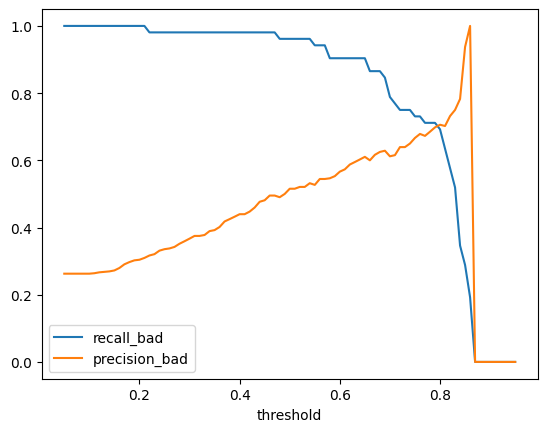

In [99]:
threshold_df.plot(x="threshold", y=["recall_bad", "precision_bad"])

In [83]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

test_loss_th, test_metrics_th, test_pred_df_th = evaluate_with_threshold(
    model=effv2_result["model"],
    loader=test_loader,
    criterion=criterion,
    device=device,
    threshold=best_threshold,
    phase="Test(thresholded)"
)

print("Test Loss:", test_loss_th)
print("Accuracy:", test_metrics_th["accuracy"])
print("Balanced Accuracy:", test_metrics_th["balanced_accuracy"])
print("Precision_bad:", test_metrics_th["precision_bad"])
print("Recall_bad:", test_metrics_th["recall_bad"])
print("F1_bad:", test_metrics_th["f1_bad"])
print("Confusion Matrix:\n", test_metrics_th["confusion_matrix"])

Test Loss: 0.3859614936702455
Accuracy: 0.9119170984455959
Balanced Accuracy: 0.8923854447439353
Precision_bad: 0.8333333333333334
Recall_bad: 0.8490566037735849
F1_bad: 0.8411214953271028
Confusion Matrix:
 [[131   9]
 [  8  45]]


Vision Transformer

In [90]:
import torch.nn as nn
import torchvision


def build_model(model_name, num_classes=2, pretrained=True):
    model_name = model_name.lower()

    if model_name == "vit_b_16":
        weights = torchvision.models.ViT_B_16_Weights.DEFAULT if pretrained else None
        model = torchvision.models.vit_b_16(weights=weights)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    return model

In [91]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

# 既存の mean, std をそのまま使う
# mean, std はすでにNotebook内で計算済みのものを利用

vit_train_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

vit_val_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [92]:
vit_train_dataset = LogoDataset(
    train_df,
    transform=vit_train_transform
)

vit_val_dataset = LogoDataset(
    val_df,
    transform=vit_val_transform
)

vit_test_dataset = LogoDataset(
    test_df,
    transform=vit_val_transform
)

In [93]:
from torch.utils.data import DataLoader

# ViTはCNNより重いので batch_size は小さめ推奨
vit_train_loader = DataLoader(
    vit_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

vit_val_loader = DataLoader(
    vit_val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

vit_test_loader = DataLoader(
    vit_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [94]:
vit_result = run_experiment_with_existing_loaders(
    train_loader=vit_train_loader,
    val_loader=vit_val_loader,
    test_loader=vit_test_loader,
    model_name="vit_b_16",
    lr=1e-4,
    weight_decay=1e-4,
    num_epochs=10,
    monitor_metric="recall_bad",
    output_dir="outputs/vit_b_16",
)


### Running experiment: vit_b_16 ###
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 211MB/s]



===== Epoch 1/10 =====


Train Loss: 0.7627 | Acc: 0.5328 | BalAcc: 0.5080 | Prec_bad: 0.2623 | Recall_bad: 0.4571 | F1_bad: 0.3333 | FNR: 0.5429 | FPR: 0.4412 | EpochTime(s): 14.55
Val   Loss: 0.5770 | Acc: 0.7374 | BalAcc: 0.5000 | Prec_bad: 0.0000 | Recall_bad: 0.0000 | F1_bad: 0.0000 | FNR: 1.0000 | FPR: 0.0000 | InfTime(s): 3.1484 | ms/img: 15.9012
Val Confusion Matrix:
[[146   0]
 [ 52   0]]
*** Best model updated: epoch=1, recall_bad=0.0000

===== Epoch 2/10 =====


Train Loss: 0.6906 | Acc: 0.6121 | BalAcc: 0.5733 | Prec_bad: 0.3279 | Recall_bad: 0.4939 | F1_bad: 0.3941 | FNR: 0.5061 | FPR: 0.3473 | EpochTime(s): 18.04
Val   Loss: 0.3782 | Acc: 0.8333 | BalAcc: 0.7570 | Prec_bad: 0.7209 | Recall_bad: 0.5962 | F1_bad: 0.6526 | FNR: 0.4038 | FPR: 0.0822 | InfTime(s): 3.0324 | ms/img: 15.3153
Val Confusion Matrix:
[[134  12]
 [ 21  31]]
*** Best model updated: epoch=2, recall_bad=0.5962

===== Epoch 3/10 =====


...

Train Loss: 0.1816 | Acc: 0.9270 | BalAcc: 0.9255 | Prec_bad: 0.8159 | Recall_bad: 0.9224 | F1_bad: 0.8659 | FNR: 0.0776 | FPR: 0.0714 | EpochTime(s): 13.82
Val   Loss: 0.2389 | Acc: 0.8939 | BalAcc: 0.8352 | Prec_bad: 0.8605 | Recall_bad: 0.7115 | F1_bad: 0.7789 | FNR: 0.2885 | FPR: 0.0411 | InfTime(s): 2.9831 | ms/img: 15.0661
Val Confusion Matrix:
[[140   6]
 [ 15  37]]

===== Epoch 8/10 =====


Train Loss: 0.1204 | Acc: 0.9635 | BalAcc: 0.9594 | Prec_bad: 0.9102 | Recall_bad: 0.9510 | F1_bad: 0.9301 | FNR: 0.0490 | FPR: 0.0322 | EpochTime(s): 13.66
Val   Loss: 0.2570 | Acc: 0.8939 | BalAcc: 0.8909 | Prec_bad: 0.7541 | Recall_bad: 0.8846 | F1_bad: 0.8142 | FNR: 0.1154 | FPR: 0.1027 | InfTime(s): 2.9641 | ms/img: 14.9702
Val Confusion Matrix:
[[131  15]
 [  6  46]]

===== Epoch 9/10 =====


Train Loss: 0.0872 | Acc: 0.9677 | BalAcc: 0.9662 | Prec_bad: 0.9147 | Recall_bad: 0.9633 | F1_bad: 0.9384 | FNR: 0.0367 | FPR: 0.0308 | EpochTime(s): 13.81
Val   Loss: 0.2027 | Acc: 0.9293 | BalAcc: 0.8901 | Prec_bad: 0.9130 | Recall_bad: 0.8077 | F1_bad: 0.8571 | FNR: 0.1923 | FPR: 0.0274 | InfTime(s): 2.9099 | ms/img: 14.6963
Val Confusion Matrix:
[[142   4]
 [ 10  42]]

===== Epoch 10/10 =====


Train Loss: 0.0682 | Acc: 0.9781 | BalAcc: 0.9759 | Prec_bad: 0.9444 | Recall_bad: 0.9714 | F1_bad: 0.9577 | FNR: 0.0286 | FPR: 0.0196 | EpochTime(s): 13.92
Val   Loss: 0.2286 | Acc: 0.8939 | BalAcc: 0.8786 | Prec_bad: 0.7719 | Recall_bad: 0.8462 | F1_bad: 0.8073 | FNR: 0.1538 | FPR: 0.0890 | InfTime(s): 2.9449 | ms/img: 14.8731
Val Confusion Matrix:
[[133  13]
 [  8  44]]

Best epoch: 3
Best recall_bad: 0.9615
Total training time (sec): 182.36
Average epoch training time (sec): 14.93



===== TEST RESULT =====
Test Loss: 0.5821
Accuracy: 0.7202
Balanced Accuracy: 0.7954
Precision_bad: 0.4951
Recall_bad: 0.9623
F1_bad: 0.6538
False Negative Rate: 0.0377
False Positive Rate: 0.3714
Specificity: 0.6286
NPV: 0.9778
Total Inference Time (sec): 2.8003
Avg Inference Time per Image (ms): 14.5094
Throughput (images/sec): 68.92
Confusion Matrix:
[[88 52]
 [ 2 51]]

Classification Report:
              precision    recall  f1-score   support

        good     0.9778    0.6286    0.7652       140
         bad     0.4951    0.9623    0.6538        53

    accuracy                         0.7202       193
   macro avg     0.7365    0.7954    0.7095       193
weighted avg     0.8452    0.7202    0.7346       193



In [95]:
vit_result["test_metrics"]

{'accuracy': 0.7202072538860104,
 'balanced_accuracy': np.float64(0.7954177897574124),
 'precision_bad': 0.49514563106796117,
 'recall_bad': 0.9622641509433962,
 'f1_bad': 0.6538461538461539,
 'false_negative_rate': np.float64(0.03773584905660377),
 'false_positive_rate': np.float64(0.37142857142857144),
 'specificity': np.float64(0.6285714285714286),
 'npv': np.float64(0.9777777777777777),
 'tn': np.int64(88),
 'fp': np.int64(52),
 'fn': np.int64(2),
 'tp': np.int64(51),
 'confusion_matrix': array([[88, 52],
        [ 2, 51]]),
 'total_inference_time_sec': 2.8003167860001668,
 'avg_inference_time_per_image_ms': 14.509413398964595,
 'throughput_images_per_sec': 68.92077387989792}

In [96]:
val_pred_df = pd.read_csv("/content/outputs/vit_b_16/best_val_predictions_vit_b_16.csv")
val_pred_df.head()

best_row, threshold_df = find_best_threshold_by_recall_constraint(
    val_pred_df,
    min_recall_bad=0.95
)

print(best_row)

threshold                0.540000
accuracy                 0.767677
balanced_accuracy        0.830084
precision_bad            0.531915
recall_bad               0.961538
f1_bad                   0.684932
false_negative_rate      0.038462
false_positive_rate      0.301370
specificity              0.698630
npv                      0.980769
tn                     102.000000
fp                      44.000000
fn                       2.000000
tp                      50.000000
Name: 49, dtype: float64


In [97]:
best_threshold = float(best_row["threshold"])
print("best_threshold:", best_threshold)

best_threshold: 0.5400000000000001


In [98]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

test_loss_th, test_metrics_th, test_pred_df_th = evaluate_with_threshold(
    model=vit_result["model"],
    loader=vit_test_loader,   # ← ここを変更
    criterion=criterion,
    device=device,
    threshold=best_threshold,
    phase="Test(thresholded)"
)

print("Test Loss:", test_loss_th)
print("Accuracy:", test_metrics_th["accuracy"])
print("Balanced Accuracy:", test_metrics_th["balanced_accuracy"])
print("Precision_bad:", test_metrics_th["precision_bad"])
print("Recall_bad:", test_metrics_th["recall_bad"])
print("F1_bad:", test_metrics_th["f1_bad"])
print("Confusion Matrix:\n", test_metrics_th["confusion_matrix"])

Test Loss: 0.5821032093287749
Accuracy: 0.7305699481865285
Balanced Accuracy: 0.7966981132075472
Precision_bad: 0.5050505050505051
Recall_bad: 0.9433962264150944
F1_bad: 0.6578947368421053
Confusion Matrix:
 [[91 49]
 [ 3 50]]


アンサンブル

Resnet18 + EfficientnetV2

In [101]:
import torch.nn.functional as F
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

@torch.no_grad()
def get_probs_and_labels(model, loader, device):
    model.eval()
    probs_list = []
    labels_list = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)[:, 1]  # badクラス確率

        probs_list.extend(probs.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

    return np.array(probs_list), np.array(labels_list)

In [102]:
resnet_probs, y_true_resnet = get_probs_and_labels(
    resnet_result["model"], test_loader, device
)

effv2_probs, y_true_effv2 = get_probs_and_labels(
    effv2_result["model"], test_loader, device
)

In [103]:
assert len(resnet_probs) == len(effv2_probs), "予測数が一致していません"
assert np.array_equal(y_true_resnet, y_true_effv2), "ラベル順が一致していません"

In [104]:
y_true = y_true_resnet

In [105]:
def evaluate_weighted_ensemble(
    probs1,
    probs2,
    y_true,
    w1=0.7,
    w2=0.3,
    threshold=0.5,
):
    ensemble_probs = w1 * probs1 + w2 * probs2
    y_pred = (ensemble_probs >= threshold).astype(int)

    metrics = {
        "w1": w1,
        "w2": w2,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_bad": precision_score(y_true, y_pred, zero_division=0),
        "recall_bad": recall_score(y_true, y_pred, zero_division=0),
        "f1_bad": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred,
        "ensemble_probs": ensemble_probs,
    }
    return metrics

In [106]:
ensemble_metrics = evaluate_weighted_ensemble(
    probs1=resnet_probs,
    probs2=effv2_probs,
    y_true=y_true,
    w1=0.7,
    w2=0.3,
    threshold=0.5,
)

print("Accuracy:", ensemble_metrics["accuracy"])
print("Balanced Accuracy:", ensemble_metrics["balanced_accuracy"])
print("Precision_bad:", ensemble_metrics["precision_bad"])
print("Recall_bad:", ensemble_metrics["recall_bad"])
print("F1_bad:", ensemble_metrics["f1_bad"])
print("Confusion Matrix:\n", ensemble_metrics["confusion_matrix"])

Accuracy: 0.9430051813471503
Balanced Accuracy: 0.948989218328841
Precision_bad: 0.85
Recall_bad: 0.9622641509433962
F1_bad: 0.9026548672566371
Confusion Matrix:
 [[131   9]
 [  2  51]]


In [107]:
weight_candidates = [0.5, 0.6, 0.7, 0.8, 0.9]
threshold_candidates = [i / 100 for i in range(10, 91, 1)]

ensemble_results = []

for w_resnet in weight_candidates:
    w_effv2 = 1.0 - w_resnet

    for th in threshold_candidates:
        metrics = evaluate_weighted_ensemble(
            probs1=resnet_probs,
            probs2=effv2_probs,
            y_true=y_true,
            w1=w_resnet,
            w2=w_effv2,
            threshold=th,
        )

        ensemble_results.append({
            "w_resnet": w_resnet,
            "w_effv2": w_effv2,
            "threshold": th,
            "accuracy": metrics["accuracy"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "precision_bad": metrics["precision_bad"],
            "recall_bad": metrics["recall_bad"],
            "f1_bad": metrics["f1_bad"],
            "confusion_matrix": metrics["confusion_matrix"],
        })

ensemble_df = pd.DataFrame(ensemble_results)
ensemble_df.sort_values("f1_bad", ascending=False).head(20)

,w_resnet,w_effv2,threshold,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,confusion_matrix
306,0.8,0.2,0.73,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
304,0.8,0.2,0.71,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
305,0.8,0.2,0.72,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
388,0.9,0.1,0.74,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
387,0.9,0.1,0.73,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
224,0.7,0.3,0.72,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
223,0.7,0.3,0.71,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
302,0.8,0.2,0.69,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
303,0.8,0.2,0.70,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
385,0.9,0.1,0.71,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"


In [108]:
best_ensemble_row = ensemble_df.sort_values("f1_bad", ascending=False).iloc[0]
best_ensemble_row

,306
w_resnet,0.8
w_effv2,0.2
threshold,0.73
accuracy,0.984456
balanced_accuracy,0.977561
precision_bad,0.980769
recall_bad,0.962264
f1_bad,0.971429
confusion_matrix,"[[139, 1], [2, 51]]"


In [109]:
best_ensemble_metrics = evaluate_weighted_ensemble(
    probs1=resnet_probs,
    probs2=effv2_probs,
    y_true=y_true,
    w1=best_ensemble_row["w_resnet"],
    w2=best_ensemble_row["w_effv2"],
    threshold=best_ensemble_row["threshold"],
)

print("Best weights:")
print("  ResNet18:", best_ensemble_metrics["w1"])
print("  EfficientNetV2-S:", best_ensemble_metrics["w2"])
print("Best threshold:", best_ensemble_metrics["threshold"])
print("Accuracy:", best_ensemble_metrics["accuracy"])
print("Balanced Accuracy:", best_ensemble_metrics["balanced_accuracy"])
print("Precision_bad:", best_ensemble_metrics["precision_bad"])
print("Recall_bad:", best_ensemble_metrics["recall_bad"])
print("F1_bad:", best_ensemble_metrics["f1_bad"])
print("Confusion Matrix:\n", best_ensemble_metrics["confusion_matrix"])

Best weights:
  ResNet18: 0.8
  EfficientNetV2-S: 0.19999999999999996
Best threshold: 0.73
Accuracy: 0.9844559585492227
Balanced Accuracy: 0.9775606469002696
Precision_bad: 0.9807692307692307
Recall_bad: 0.9622641509433962
F1_bad: 0.9714285714285714
Confusion Matrix:
 [[139   1]
 [  2  51]]


In [110]:
comparison = pd.DataFrame([
    {
        "model": "resnet18",
        "accuracy": resnet_result["test_metrics"]["accuracy"],
        "balanced_accuracy": resnet_result["test_metrics"]["balanced_accuracy"],
        "precision_bad": resnet_result["test_metrics"]["precision_bad"],
        "recall_bad": resnet_result["test_metrics"]["recall_bad"],
        "f1_bad": resnet_result["test_metrics"]["f1_bad"],
        "confusion_matrix": resnet_result["test_metrics"]["confusion_matrix"].tolist(),
    },
    {
        "model": "efficientnet_v2_s",
        "accuracy": effv2_result["test_metrics"]["accuracy"],
        "balanced_accuracy": effv2_result["test_metrics"]["balanced_accuracy"],
        "precision_bad": effv2_result["test_metrics"]["precision_bad"],
        "recall_bad": effv2_result["test_metrics"]["recall_bad"],
        "f1_bad": effv2_result["test_metrics"]["f1_bad"],
        "confusion_matrix": effv2_result["test_metrics"]["confusion_matrix"].tolist(),
    },
    {
        "model": "resnet18 + efficientnet_v2_s ensemble",
        "accuracy": best_ensemble_metrics["accuracy"],
        "balanced_accuracy": best_ensemble_metrics["balanced_accuracy"],
        "precision_bad": best_ensemble_metrics["precision_bad"],
        "recall_bad": best_ensemble_metrics["recall_bad"],
        "f1_bad": best_ensemble_metrics["f1_bad"],
        "confusion_matrix": best_ensemble_metrics["confusion_matrix"].tolist(),
    },
])

comparison.sort_values("f1_bad", ascending=False)

,model,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,confusion_matrix
2,resnet18 + efficientnet_v2_s ensemble,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
0,resnet18,0.937824,0.945418,0.836066,0.962264,0.894737,"[[130, 10], [2, 51]]"
1,efficientnet_v2_s,0.829016,0.870418,0.621951,0.962264,0.755556,"[[109, 31], [2, 51]]"


アンサンブル改善

In [111]:
@torch.no_grad()
def get_probs_and_labels(model, loader, device):
    model.eval()
    probs_list = []
    labels_list = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)[:, 1]  # badクラス確率

        probs_list.extend(probs.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

    return np.array(probs_list), np.array(labels_list)

In [112]:
resnet_val_probs, y_val_resnet = get_probs_and_labels(
    resnet_result["model"], val_loader, device
)

effv2_val_probs, y_val_effv2 = get_probs_and_labels(
    effv2_result["model"], val_loader, device
)

assert len(resnet_val_probs) == len(effv2_val_probs), "validation予測数が一致していません"
assert np.array_equal(y_val_resnet, y_val_effv2), "validationラベル順が一致していません"

y_val = y_val_resnet

In [113]:
def evaluate_weighted_ensemble(
    probs1,
    probs2,
    y_true,
    w1=0.7,
    w2=0.3,
    threshold=0.5,
):
    ensemble_probs = w1 * probs1 + w2 * probs2
    y_pred = (ensemble_probs >= threshold).astype(int)

    metrics = {
        "w1": w1,
        "w2": w2,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_bad": precision_score(y_true, y_pred, zero_division=0),
        "recall_bad": recall_score(y_true, y_pred, zero_division=0),
        "f1_bad": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred,
        "ensemble_probs": ensemble_probs,
    }
    return metrics

In [114]:
weight_candidates = np.arange(0.50, 0.96, 0.05)   # ResNet18 の重み
threshold_candidates = np.arange(0.10, 0.91, 0.01)

ensemble_val_results = []

for w_resnet in weight_candidates:
    w_effv2 = 1.0 - w_resnet

    for th in threshold_candidates:
        metrics = evaluate_weighted_ensemble(
            probs1=resnet_val_probs,
            probs2=effv2_val_probs,
            y_true=y_val,
            w1=w_resnet,
            w2=w_effv2,
            threshold=th,
        )

        ensemble_val_results.append({
            "w_resnet": w_resnet,
            "w_effv2": w_effv2,
            "threshold": th,
            "accuracy": metrics["accuracy"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "precision_bad": metrics["precision_bad"],
            "recall_bad": metrics["recall_bad"],
            "f1_bad": metrics["f1_bad"],
            "confusion_matrix": metrics["confusion_matrix"],
        })

ensemble_val_df = pd.DataFrame(ensemble_val_results)
ensemble_val_df.sort_values("f1_bad", ascending=False).head(20)

,w_resnet,w_effv2,threshold,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,confusion_matrix
805,0.95,0.05,0.86,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"
474,0.75,0.25,0.79,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"
475,0.75,0.25,0.80,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"
473,0.75,0.25,0.78,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"
723,0.90,0.10,0.85,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"
482,0.75,0.25,0.87,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"
483,0.75,0.25,0.88,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"
476,0.75,0.25,0.81,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"
721,0.90,0.10,0.83,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"
722,0.90,0.10,0.84,0.994949,0.990385,1.0,0.980769,0.990291,"[[146, 0], [1, 51]]"


In [115]:
best_ensemble_val = ensemble_val_df.sort_values(
    ["f1_bad", "balanced_accuracy", "precision_bad"],
    ascending=False
).iloc[0]

best_ensemble_val

,231
w_resnet,0.6
w_effv2,0.4
threshold,0.79
accuracy,0.994949
balanced_accuracy,0.990385
precision_bad,1.0
recall_bad,0.980769
f1_bad,0.990291
confusion_matrix,"[[146, 0], [1, 51]]"


In [116]:
best_w_resnet = float(best_ensemble_val["w_resnet"])
best_w_effv2 = float(best_ensemble_val["w_effv2"])
best_threshold = float(best_ensemble_val["threshold"])

print("Best validation setting")
print("ResNet18 weight:", best_w_resnet)
print("EfficientNetV2-S weight:", best_w_effv2)
print("Threshold:", best_threshold)
print("Validation F1_bad:", best_ensemble_val["f1_bad"])
print("Validation Balanced Accuracy:", best_ensemble_val["balanced_accuracy"])
print("Validation Precision_bad:", best_ensemble_val["precision_bad"])
print("Validation Recall_bad:", best_ensemble_val["recall_bad"])
print("Validation Confusion Matrix:\n", best_ensemble_val["confusion_matrix"])

Best validation setting
ResNet18 weight: 0.6000000000000001
EfficientNetV2-S weight: 0.3999999999999999
Threshold: 0.7899999999999996
Validation F1_bad: 0.9902912621359223
Validation Balanced Accuracy: 0.9903846153846154
Validation Precision_bad: 1.0
Validation Recall_bad: 0.9807692307692307
Validation Confusion Matrix:
 [[146   0]
 [  1  51]]


In [117]:
resnet_test_probs, y_test_resnet = get_probs_and_labels(
    resnet_result["model"], test_loader, device
)

effv2_test_probs, y_test_effv2 = get_probs_and_labels(
    effv2_result["model"], test_loader, device
)

assert len(resnet_test_probs) == len(effv2_test_probs), "test予測数が一致していません"
assert np.array_equal(y_test_resnet, y_test_effv2), "testラベル順が一致していません"

y_test = y_test_resnet

In [118]:
best_ensemble_test_metrics = evaluate_weighted_ensemble(
    probs1=resnet_test_probs,
    probs2=effv2_test_probs,
    y_true=y_test,
    w1=best_w_resnet,
    w2=best_w_effv2,
    threshold=best_threshold,
)

print("Best weights:")
print("  ResNet18:", best_ensemble_test_metrics["w1"])
print("  EfficientNetV2-S:", best_ensemble_test_metrics["w2"])
print("Best threshold:", best_ensemble_test_metrics["threshold"])
print("Accuracy:", best_ensemble_test_metrics["accuracy"])
print("Balanced Accuracy:", best_ensemble_test_metrics["balanced_accuracy"])
print("Precision_bad:", best_ensemble_test_metrics["precision_bad"])
print("Recall_bad:", best_ensemble_test_metrics["recall_bad"])
print("F1_bad:", best_ensemble_test_metrics["f1_bad"])
print("Confusion Matrix:\n", best_ensemble_test_metrics["confusion_matrix"])

Best weights:
  ResNet18: 0.6000000000000001
  EfficientNetV2-S: 0.3999999999999999
Best threshold: 0.7899999999999996
Accuracy: 0.9689119170984456
Balanced Accuracy: 0.9492587601078167
Precision_bad: 0.9795918367346939
Recall_bad: 0.9056603773584906
F1_bad: 0.9411764705882353
Confusion Matrix:
 [[139   1]
 [  5  48]]


In [119]:
comparison = pd.DataFrame([
    {
        "model": "resnet18",
        "accuracy": resnet_result["test_metrics"]["accuracy"],
        "balanced_accuracy": resnet_result["test_metrics"]["balanced_accuracy"],
        "precision_bad": resnet_result["test_metrics"]["precision_bad"],
        "recall_bad": resnet_result["test_metrics"]["recall_bad"],
        "f1_bad": resnet_result["test_metrics"]["f1_bad"],
        "confusion_matrix": resnet_result["test_metrics"]["confusion_matrix"].tolist(),
    },
    {
        "model": "efficientnet_v2_s",
        "accuracy": effv2_result["test_metrics"]["accuracy"],
        "balanced_accuracy": effv2_result["test_metrics"]["balanced_accuracy"],
        "precision_bad": effv2_result["test_metrics"]["precision_bad"],
        "recall_bad": effv2_result["test_metrics"]["recall_bad"],
        "f1_bad": effv2_result["test_metrics"]["f1_bad"],
        "confusion_matrix": effv2_result["test_metrics"]["confusion_matrix"].tolist(),
    },
    {
        "model": "resnet18 + efficientnet_v2_s ensemble (val-tuned)",
        "accuracy": best_ensemble_test_metrics["accuracy"],
        "balanced_accuracy": best_ensemble_test_metrics["balanced_accuracy"],
        "precision_bad": best_ensemble_test_metrics["precision_bad"],
        "recall_bad": best_ensemble_test_metrics["recall_bad"],
        "f1_bad": best_ensemble_test_metrics["f1_bad"],
        "confusion_matrix": best_ensemble_test_metrics["confusion_matrix"].tolist(),
    },
])

comparison.sort_values("f1_bad", ascending=False)

,model,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,confusion_matrix
2,resnet18 + efficientnet_v2_s ensemble (val-tuned),0.968912,0.949259,0.979592,0.905660,0.941176,"[[139, 1], [5, 48]]"
0,resnet18,0.937824,0.945418,0.836066,0.962264,0.894737,"[[130, 10], [2, 51]]"
1,efficientnet_v2_s,0.829016,0.870418,0.621951,0.962264,0.755556,"[[109, 31], [2, 51]]"


Resnet + ConvNext

In [120]:
resnet_probs, y_true_resnet = get_probs_and_labels(
    resnet_result["model"], test_loader, device
)

effv2_probs, y_true_effv2 = get_probs_and_labels(
    effv2_result["model"], test_loader, device
)

convnext_probs, y_true_convnext = get_probs_and_labels(
    convnext_result["model"], test_loader, device
)

assert len(resnet_probs) == len(effv2_probs) == len(convnext_probs), "予測数が一致していません"
assert np.array_equal(y_true_resnet, y_true_effv2), "ResNet と EffV2 のラベル順が一致していません"
assert np.array_equal(y_true_resnet, y_true_convnext), "ResNet と ConvNeXt のラベル順が一致していません"

y_true = y_true_resnet

In [121]:
def evaluate_weighted_ensemble_2models(
    probs1,
    probs2,
    y_true,
    w1=0.7,
    w2=0.3,
    threshold=0.5,
):
    ensemble_probs = w1 * probs1 + w2 * probs2
    y_pred = (ensemble_probs >= threshold).astype(int)

    metrics = {
        "w1": w1,
        "w2": w2,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_bad": precision_score(y_true, y_pred, zero_division=0),
        "recall_bad": recall_score(y_true, y_pred, zero_division=0),
        "f1_bad": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred,
        "ensemble_probs": ensemble_probs,
    }
    return metrics

In [122]:
resnet_convnext_metrics = evaluate_weighted_ensemble_2models(
    probs1=resnet_probs,
    probs2=convnext_probs,
    y_true=y_true,
    w1=0.7,
    w2=0.3,
    threshold=0.5,
)

print("Accuracy:", resnet_convnext_metrics["accuracy"])
print("Balanced Accuracy:", resnet_convnext_metrics["balanced_accuracy"])
print("Precision_bad:", resnet_convnext_metrics["precision_bad"])
print("Recall_bad:", resnet_convnext_metrics["recall_bad"])
print("F1_bad:", resnet_convnext_metrics["f1_bad"])
print("Confusion Matrix:\n", resnet_convnext_metrics["confusion_matrix"])

Accuracy: 0.9378238341968912
Balanced Accuracy: 0.9454177897574124
Precision_bad: 0.8360655737704918
Recall_bad: 0.9622641509433962
F1_bad: 0.8947368421052632
Confusion Matrix:
 [[130  10]
 [  2  51]]


In [123]:
weight_candidates = [0.5, 0.6, 0.7, 0.8, 0.9]
threshold_candidates = [i / 100 for i in range(10, 91, 1)]

resnet_convnext_results = []

for w_resnet in weight_candidates:
    w_convnext = 1.0 - w_resnet

    for th in threshold_candidates:
        metrics = evaluate_weighted_ensemble_2models(
            probs1=resnet_probs,
            probs2=convnext_probs,
            y_true=y_true,
            w1=w_resnet,
            w2=w_convnext,
            threshold=th,
        )

        resnet_convnext_results.append({
            "w_resnet": w_resnet,
            "w_convnext": w_convnext,
            "threshold": th,
            "accuracy": metrics["accuracy"],
            "balanced_accuracy": metrics["balanced_accuracy"],
            "precision_bad": metrics["precision_bad"],
            "recall_bad": metrics["recall_bad"],
            "f1_bad": metrics["f1_bad"],
            "confusion_matrix": metrics["confusion_matrix"],
        })

resnet_convnext_df = pd.DataFrame(resnet_convnext_results)
resnet_convnext_df.sort_values("f1_bad", ascending=False).head(20)

,w_resnet,w_convnext,threshold,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,confusion_matrix
53,0.5,0.5,0.63,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
52,0.5,0.5,0.62,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
51,0.5,0.5,0.61,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
301,0.8,0.2,0.68,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
302,0.8,0.2,0.69,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
303,0.8,0.2,0.70,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
304,0.8,0.2,0.71,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
55,0.5,0.5,0.65,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
300,0.8,0.2,0.67,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
54,0.5,0.5,0.64,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"


In [124]:
best_resnet_convnext_row = resnet_convnext_df.sort_values("f1_bad", ascending=False).iloc[0]
best_resnet_convnext_row

,53
w_resnet,0.5
w_convnext,0.5
threshold,0.63
accuracy,0.979275
balanced_accuracy,0.973989
precision_bad,0.962264
recall_bad,0.962264
f1_bad,0.962264
confusion_matrix,"[[138, 2], [2, 51]]"


In [125]:
best_resnet_convnext_metrics = evaluate_weighted_ensemble_2models(
    probs1=resnet_probs,
    probs2=convnext_probs,
    y_true=y_true,
    w1=best_resnet_convnext_row["w_resnet"],
    w2=best_resnet_convnext_row["w_convnext"],
    threshold=best_resnet_convnext_row["threshold"],
)

print("Best weights:")
print("  ResNet18:", best_resnet_convnext_metrics["w1"])
print("  ConvNeXt-Tiny:", best_resnet_convnext_metrics["w2"])
print("Best threshold:", best_resnet_convnext_metrics["threshold"])
print("Accuracy:", best_resnet_convnext_metrics["accuracy"])
print("Balanced Accuracy:", best_resnet_convnext_metrics["balanced_accuracy"])
print("Precision_bad:", best_resnet_convnext_metrics["precision_bad"])
print("Recall_bad:", best_resnet_convnext_metrics["recall_bad"])
print("F1_bad:", best_resnet_convnext_metrics["f1_bad"])
print("Confusion Matrix:\n", best_resnet_convnext_metrics["confusion_matrix"])

Best weights:
  ResNet18: 0.5
  ConvNeXt-Tiny: 0.5
Best threshold: 0.63
Accuracy: 0.9792746113989638
Balanced Accuracy: 0.973989218328841
Precision_bad: 0.9622641509433962
Recall_bad: 0.9622641509433962
F1_bad: 0.9622641509433962
Confusion Matrix:
 [[138   2]
 [  2  51]]


ResNet + EffV2 + ConvNeXt

In [126]:
def evaluate_weighted_ensemble_3models(
    probs1,
    probs2,
    probs3,
    y_true,
    w1=0.5,
    w2=0.3,
    w3=0.2,
    threshold=0.5,
):
    ensemble_probs = w1 * probs1 + w2 * probs2 + w3 * probs3
    y_pred = (ensemble_probs >= threshold).astype(int)

    metrics = {
        "w1": w1,
        "w2": w2,
        "w3": w3,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_bad": precision_score(y_true, y_pred, zero_division=0),
        "recall_bad": recall_score(y_true, y_pred, zero_division=0),
        "f1_bad": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "y_pred": y_pred,
        "ensemble_probs": ensemble_probs,
    }
    return metrics

In [127]:
resnet_effv2_convnext_metrics = evaluate_weighted_ensemble_3models(
    probs1=resnet_probs,
    probs2=effv2_probs,
    probs3=convnext_probs,
    y_true=y_true,
    w1=0.5,
    w2=0.3,
    w3=0.2,
    threshold=0.5,
)

print("Accuracy:", resnet_effv2_convnext_metrics["accuracy"])
print("Balanced Accuracy:", resnet_effv2_convnext_metrics["balanced_accuracy"])
print("Precision_bad:", resnet_effv2_convnext_metrics["precision_bad"])
print("Recall_bad:", resnet_effv2_convnext_metrics["recall_bad"])
print("F1_bad:", resnet_effv2_convnext_metrics["f1_bad"])
print("Confusion Matrix:\n", resnet_effv2_convnext_metrics["confusion_matrix"])

Accuracy: 0.9430051813471503
Balanced Accuracy: 0.948989218328841
Precision_bad: 0.85
Recall_bad: 0.9622641509433962
F1_bad: 0.9026548672566371
Confusion Matrix:
 [[131   9]
 [  2  51]]


In [128]:
weight_candidates_resnet = [0.4, 0.5, 0.6, 0.7]
weight_candidates_effv2 = [0.1, 0.2, 0.3, 0.4]
threshold_candidates = [i / 100 for i in range(10, 91, 1)]

resnet_effv2_convnext_results = []

for w_resnet in weight_candidates_resnet:
    for w_effv2 in weight_candidates_effv2:
        w_convnext = 1.0 - w_resnet - w_effv2

        if w_convnext <= 0:
            continue

        for th in threshold_candidates:
            metrics = evaluate_weighted_ensemble_3models(
                probs1=resnet_probs,
                probs2=effv2_probs,
                probs3=convnext_probs,
                y_true=y_true,
                w1=w_resnet,
                w2=w_effv2,
                w3=w_convnext,
                threshold=th,
            )

            resnet_effv2_convnext_results.append({
                "w_resnet": w_resnet,
                "w_effv2": w_effv2,
                "w_convnext": w_convnext,
                "threshold": th,
                "accuracy": metrics["accuracy"],
                "balanced_accuracy": metrics["balanced_accuracy"],
                "precision_bad": metrics["precision_bad"],
                "recall_bad": metrics["recall_bad"],
                "f1_bad": metrics["f1_bad"],
                "confusion_matrix": metrics["confusion_matrix"],
            })

resnet_effv2_convnext_df = pd.DataFrame(resnet_effv2_convnext_results)
resnet_effv2_convnext_df.sort_values("f1_bad", ascending=False).head(20)

,w_resnet,w_effv2,w_convnext,threshold,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,confusion_matrix
54,0.4,0.1,5.000000e-01,0.64,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
52,0.4,0.1,5.000000e-01,0.62,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
53,0.4,0.1,5.000000e-01,0.63,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
544,0.5,0.3,2.000000e-01,0.68,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
461,0.5,0.2,3.000000e-01,0.66,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
705,0.6,0.1,3.000000e-01,0.67,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
706,0.6,0.1,3.000000e-01,0.68,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
951,0.7,0.1,2.000000e-01,0.70,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
950,0.7,0.1,2.000000e-01,0.69,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
786,0.6,0.2,2.000000e-01,0.67,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"


In [129]:
best_resnet_effv2_convnext_row = resnet_effv2_convnext_df.sort_values("f1_bad", ascending=False).iloc[0]
best_resnet_effv2_convnext_row

,54
w_resnet,0.4
w_effv2,0.1
w_convnext,0.5
threshold,0.64
accuracy,0.984456
balanced_accuracy,0.977561
precision_bad,0.980769
recall_bad,0.962264
f1_bad,0.971429
confusion_matrix,"[[139, 1], [2, 51]]"


In [132]:
best_resnet_effv2_convnext_metrics = evaluate_weighted_ensemble_3models(
    probs1=resnet_probs,
    probs2=effv2_probs,
    probs3=convnext_probs,
    y_true=y_true,
    w1=best_resnet_effv2_convnext_row["w_resnet"],
    w2=best_resnet_effv2_convnext_row["w_effv2"],
    w3=best_resnet_effv2_convnext_row["w_convnext"],
    threshold=best_resnet_effv2_convnext_row["threshold"],
)

print("Best weights:")
print("  ResNet18:", best_resnet_effv2_convnext_metrics["w1"])
print("  EfficientNetV2-S:", best_resnet_effv2_convnext_metrics["w2"])
print("  ConvNeXt-Tiny:", best_resnet_effv2_convnext_metrics["w3"])
print("Best threshold:", best_resnet_effv2_convnext_metrics["threshold"])
print("Accuracy:", best_resnet_effv2_convnext_metrics["accuracy"])
print("Balanced Accuracy:", best_resnet_effv2_convnext_metrics["balanced_accuracy"])
print("Precision_bad:", best_resnet_effv2_convnext_metrics["precision_bad"])
print("Recall_bad:", best_resnet_effv2_convnext_metrics["recall_bad"])
print("F1_bad:", best_resnet_effv2_convnext_metrics["f1_bad"])
print("Confusion Matrix:\n", best_resnet_effv2_convnext_metrics["confusion_matrix"])

Best weights:
  ResNet18: 0.4
  EfficientNetV2-S: 0.1
  ConvNeXt-Tiny: 0.5
Best threshold: 0.64
Accuracy: 0.9844559585492227
Balanced Accuracy: 0.9775606469002696
Precision_bad: 0.9807692307692307
Recall_bad: 0.9622641509433962
F1_bad: 0.9714285714285714
Confusion Matrix:
 [[139   1]
 [  2  51]]


In [133]:
comparison_ensemble = pd.DataFrame([
    {
        "model": "resnet18",
        "accuracy": resnet_result["test_metrics"]["accuracy"],
        "balanced_accuracy": resnet_result["test_metrics"]["balanced_accuracy"],
        "precision_bad": resnet_result["test_metrics"]["precision_bad"],
        "recall_bad": resnet_result["test_metrics"]["recall_bad"],
        "f1_bad": resnet_result["test_metrics"]["f1_bad"],
        "confusion_matrix": resnet_result["test_metrics"]["confusion_matrix"].tolist(),
    },
    {
        "model": "resnet18 + efficientnet_v2_s",
        "accuracy": best_ensemble_metrics["accuracy"],
        "balanced_accuracy": best_ensemble_metrics["balanced_accuracy"],
        "precision_bad": best_ensemble_metrics["precision_bad"],
        "recall_bad": best_ensemble_metrics["recall_bad"],
        "f1_bad": best_ensemble_metrics["f1_bad"],
        "confusion_matrix": best_ensemble_metrics["confusion_matrix"].tolist(),
    },
    {
        "model": "resnet18 + convnext_tiny",
        "accuracy": best_resnet_convnext_metrics["accuracy"],
        "balanced_accuracy": best_resnet_convnext_metrics["balanced_accuracy"],
        "precision_bad": best_resnet_convnext_metrics["precision_bad"],
        "recall_bad": best_resnet_convnext_metrics["recall_bad"],
        "f1_bad": best_resnet_convnext_metrics["f1_bad"],
        "confusion_matrix": best_resnet_convnext_metrics["confusion_matrix"].tolist(),
    },
    {
        "model": "resnet18 + efficientnet_v2_s + convnext_tiny",
        "accuracy": best_resnet_effv2_convnext_metrics["accuracy"],
        "balanced_accuracy": best_resnet_effv2_convnext_metrics["balanced_accuracy"],
        "precision_bad": best_resnet_effv2_convnext_metrics["precision_bad"],
        "recall_bad": best_resnet_effv2_convnext_metrics["recall_bad"],
        "f1_bad": best_resnet_effv2_convnext_metrics["f1_bad"],
        "confusion_matrix": best_resnet_effv2_convnext_metrics["confusion_matrix"].tolist(),
    },
])

comparison_ensemble.sort_values("f1_bad", ascending=False).reset_index(drop=True)

,model,accuracy,balanced_accuracy,precision_bad,recall_bad,f1_bad,confusion_matrix
0,resnet18 + efficientnet_v2_s,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
1,resnet18 + efficientnet_v2_s + convnext_tiny,0.984456,0.977561,0.980769,0.962264,0.971429,"[[139, 1], [2, 51]]"
2,resnet18 + convnext_tiny,0.979275,0.973989,0.962264,0.962264,0.962264,"[[138, 2], [2, 51]]"
3,resnet18,0.937824,0.945418,0.836066,0.962264,0.894737,"[[130, 10], [2, 51]]"
